<a href="https://colab.research.google.com/github/nbrav/NeuroAgents/blob/main/notebooks/motornet_feedback_driven_plasticity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Building a network

The purpose of this notebook is to create a network to control an effector, and to train it to perform a task through the optimization process. We will also briefly cover how to save and re-load a network.

For how to build an effector and environment from scratch, feel free to look up the `1-build-effector.ipynb` and `3-environments.ipynb` notebooks.

Let's start by importing what we need.


In [ ]:
print ("Hello world")

Hello world


In [ ]:
import os
import sys
import json
import numpy as np
import torch as th
import matplotlib.pyplot as plt

motornet_in_cwd = os.path.exists("MotorNet") or os.path.exists("motornet")
colab_env = 'google.colab' in str(get_ipython()) if hasattr(__builtins__,'__IPYTHON__') else False
colab_initialized = True if motornet_in_cwd else False

if colab_env and not colab_initialized:
  !pip install gymnasium>=2.8
  !pip install git+https://github.com/motornet-org/MotorNet
  # !pip install git+https://github.com/OlivierCodol/MotorNet@pytorch
  sys.path.append('MotorNet')
  print("Running cell using COLAB initialization...")
elif colab_env and colab_initialized:
  print("Already initialized using COLAB initialization.")
else:
  paths = [p for p in sys.path if os.path.exists(p)]
  local_initialized = True if [p for p in paths if "MotorNet" in os.listdir(p)] else False
  if local_initialized:
    %load_ext autoreload
    %autoreload 2
    print("Already initialized using LOCAL initialization.")
  else:
    path = [p for p in paths if p.__contains__("examples")]
    if len(path) != 1:
      raise ValueError("Path to MotorNet could not be determined with certainty.")
    else:
      path = path[0]
    sys.path.append(os.path.dirname(path[:path.rfind('examples')]))
    %load_ext autoreload
    %autoreload 2
    print("Running cell using LOCAL initialization...")

  Cloning https://github.com/motornet-org/MotorNet to /tmp/pip-req-build-gt7cza7y
  Running command git clone --filter=blob:none --quiet https://github.com/motornet-org/MotorNet /tmp/pip-req-build-gt7cza7y
  Resolved https://github.com/motornet-org/MotorNet to commit ad606747396611689136d9e3a915c80500efeebe
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for motornet: filename=motornet-0.3.0-py3-none-any.whl size=52718 sha256=a60ab938a7338ee9a7b7a069e850f55ace4e28c6598b48fa21d9556ecf5efdd7
  Stored in directory: /tmp/pip-ephem-wheel-cache-rlhy3_cb/wheels/e8/68/4a/b5a5d5f622b3850205d1f1512c78078f0e9423954ca9f3a27b
Successfully built motornet
Running cell using COLAB initialization...


In [ ]:
import motornet as mn

print('All packages imported.')
print('pytorch version: ' + th.__version__)
print('numpy version: ' + np.__version__)
print('motornet version: ' + mn.__version__)

All packages imported.
pytorch version: 2.11.0+cpu
numpy version: 2.0.2
motornet version: 0.3.0



# I. Introduction

Since the purpose of this notebook is not to show how to build an effector or an environment, we will use a pre-built effector and environment that comes with the `motornet` toolbox. This is a 4-muscles point mass plant, with `ReluMuscle` actuators, and a simple random-to-random position reaching task.

Generally speaking, the objects we create follow the hierarchical structure illustrated below.




<img src="https://github.com/OlivierCodol/MotorNet/blob/master/examples/img/hierarchy.png?raw=1" alt="drawing" width="500"/>


# II. Building the model

## II. 1. `Effector` and `Environment` instances.
All the elements below take from previous tutorials, so we are just repeating them here.

Note that we specify the maximum duration of an episode to be 1 sec. We set this up explicitly here, but this is actually the default if no value is provided.

In [ ]:
effector = mn.effector.ReluPointMass24()
env = mn.environment.RandomTargetReach(effector=effector, max_ep_duration=1.)

## II. 2. Building the network

This step simply reduces to building a `torch.nn.Module` subclass. If you are not sure on how to achieve that, there are many tutorials available online for learning PyTorch basics.

A good and simple model for this kind of task is to have one recurrent layer receiving observation inputs, so the input dimension is the size of the observation vector. Here we specify the recurrent layer to be one layer of 32 Gated Recurrent Units (GRUs). The output layer is a simple fully connected linear layer, with a sigmoid non-linearity.

Note that we initialize the fully connected layer's bias to be `-5`, to ensure we start the training with low output forces and therefore a more stable situation. Also note that the action that should be input into the environment should be bounded from 0 to 1, which the sigmoid guarantees.

In [ ]:
class Policy(th.nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, output_dim: int, device):
        super().__init__()
        self.device = device
        self.hidden_dim = hidden_dim
        self.n_layers = 1

        self.gru = th.nn.GRU(input_dim, hidden_dim, 1, batch_first=True)
        self.fc = th.nn.Linear(hidden_dim, output_dim)
        self.sigmoid = th.nn.Sigmoid()

        # the default initialization in torch isn't ideal
        for name, param in self.named_parameters():
            if name == "gru.weight_ih_l0":
                th.nn.init.xavier_uniform_(param)
            elif name == "gru.weight_hh_l0":
                th.nn.init.orthogonal_(param)
            elif name == "gru.bias_ih_l0":
                th.nn.init.zeros_(param)
            elif name == "gru.bias_hh_l0":
                th.nn.init.zeros_(param)
            elif name == "fc.weight":
                th.nn.init.xavier_uniform_(param)
            elif name == "fc.bias":
                th.nn.init.constant_(param, -5.)
            else:
                raise ValueError

        self.to(device)

    def forward(self, x, h0):
        y, h = self.gru(x[:, None, :], h0)
        u = self.sigmoid(self.fc(y)).squeeze(dim=1)
        return u, h

    def init_hidden(self, batch_size):
        weight = next(self.parameters()).data
        hidden = weight.new(self.n_layers, batch_size, self.hidden_dim).zero_().to(self.device)
        return hidden

device = th.device("cpu")

policy = Policy(env.observation_space.shape[0], 32, env.n_muscles, device=device)
optimizer = th.optim.Adam(policy.parameters(), lr=10**-3)

We can then train the `Policy` network like we would any PyTorch model. The output of the `Policy` is then passed as input to the `Environment` object using the `Environment.step()` method. The `obs` and `info` ouputs are then collected and used for the loss computation and the backward pass.

Importantly, adding some clipping greatly improves the training process for motor tasks in general.

In [ ]:
batch_size = 32
n_batch = 6000
losses = []
interval = 250

def l1(x, y):
  """L1 loss"""
  return th.mean(th.sum(th.abs(x - y), dim=-1))

for batch in range(n_batch):
  # initialize batch
  h = policy.init_hidden(batch_size=batch_size)
  obs, info = env.reset(options={"batch_size": batch_size})
  terminated = False

  # initial positions and targets
  xy = [info["states"]["fingertip"][:, None, :]]
  tg = [info["goal"][:, None, :]]

  # simulate whole episode
  while not terminated:  # will run until `max_ep_duration` is reached
    action, h = policy(obs, h)
    obs, reward, terminated, truncated, info = env.step(action=action)

    xy.append(info["states"]["fingertip"][:, None, :])  # trajectories
    tg.append(info["goal"][:, None, :])  # targets

  # concatenate into a (batch_size, n_timesteps, xy) tensor
  xy = th.cat(xy, axis=1)
  tg = th.cat(tg, axis=1)
  loss = l1(xy, tg)  # L1 loss on position

  # backward pass & update weights
  optimizer.zero_grad()
  loss.backward()
  th.nn.utils.clip_grad_norm_(policy.parameters(), max_norm=1.)  # important!
  optimizer.step()
  losses.append(loss.item())

  if (batch % interval == 0) and (batch != 0):
    print("Batch {}/{} Done, mean policy loss: {}".format(batch, n_batch, sum(losses[-interval:])/interval))

Batch 250/6000 Done, mean policy loss: 0.6823256098031998
Batch 500/6000 Done, mean policy loss: 0.2742290591597557
Batch 750/6000 Done, mean policy loss: 0.2070844192504883
Batch 1000/6000 Done, mean policy loss: 0.1804046881198883
Batch 1250/6000 Done, mean policy loss: 0.16460991820693016
Batch 1500/6000 Done, mean policy loss: 0.15411442336440087
Batch 1750/6000 Done, mean policy loss: 0.14744754755496978
Batch 2000/6000 Done, mean policy loss: 0.142021759390831
Batch 2250/6000 Done, mean policy loss: 0.13679210624098778
Batch 2500/6000 Done, mean policy loss: 0.13293800529837607
Batch 2750/6000 Done, mean policy loss: 0.12814378720521927
Batch 3000/6000 Done, mean policy loss: 0.12700807201862335
Batch 3250/6000 Done, mean policy loss: 0.12689339232444763
Batch 3500/6000 Done, mean policy loss: 0.12162153577804566
Batch 3750/6000 Done, mean policy loss: 0.1203802016377449
Batch 4000/6000 Done, mean policy loss: 0.11935523122549058
Batch 4250/6000 Done, mean policy loss: 0.11738905

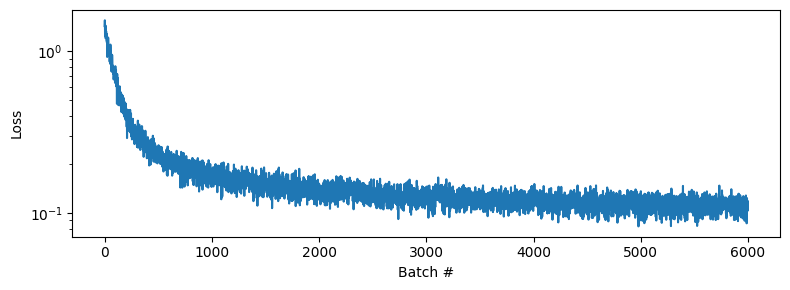

In [ ]:
def plot_training_log(log):
  fig, axs = plt.subplots(1, 1)
  fig.set_tight_layout(True)
  fig.set_size_inches((8, 3))

  axs.semilogy(log)

  axs.set_ylabel("Loss")
  axs.set_xlabel("Batch #")
  plt.show()

plot_training_log(losses)

# III. Evaluating performance

A forward pass on the model (with `deterministic=True`) will yield the evaluation behaviour.

We can plot the resulting states to quickly visualize what the network is doing.


In [ ]:
plotor = mn.plotor.plot_pos_over_time

def plot_simulations(xy, target_xy):
  target_x = target_xy[:, -1, 0]
  target_y = target_xy[:, -1, 1]

  plt.figure(figsize=(10,3))

  plt.subplot(1,2,1)
  plt.ylim([-1.1, 1.1])
  plt.xlim([-1.1, 1.1])
  plotor(axis=plt.gca(), cart_results=xy)
  plt.scatter(target_x, target_y)

  plt.subplot(1,2,2)
  plt.ylim([-2, 2])
  plt.xlim([-2, 2])
  plotor(axis=plt.gca(), cart_results=xy - target_xy)
  plt.axhline(0, c="grey")
  plt.axvline(0, c="grey")
  plt.xlabel("X distance to target")
  plt.ylabel("Y distance to target")
  plt.show()


plot_simulations(xy=th.detach(xy), target_xy=th.detach(tg))


NameError: name 'xy' is not defined

# IV. Saving the model

Next, we can save the network like we would any PyTorch model. We will also save the training history as a `.json` file, and the environment's configuration information for later reference.


In [ ]:
import os

os.makedirs("save", exist_ok=True)

weight_file = os.path.join("save", "weights.pt")
log_file    = os.path.join("save", "log.json")
cfg_file    = os.path.join("save", "cfg.json")

# Save model weights
th.save(policy.state_dict(), weight_file)

# Save training history
with open(log_file, "w") as f:
    json.dump(losses, f)

# Save environment configuration
cfg = env.get_save_config()
with open(cfg_file, "w") as f:
    json.dump(cfg, f)

print("Done.")

Done.


In [ ]:

weight_file = os.path.join("save", "weights")
log_file = os.path.join("save", "log.json")
cfg_file = os.path.join("save", "cfg.json")



In [ ]:

# save model weights
th.save(policy.state_dict(), weight_file)


# save training history (log)
with open(log_file, 'w') as file:
  json.dump(losses, file)


# save environment configuration dictionary
cfg = env.get_save_config()
with open(cfg_file, 'w') as file:
  json.dump(cfg, file)


print("done.")


done.



# V. Loading the model

## V. 1. The configuration file
This file is what the `Environment.get_save_config()` method produces. It contains a dictionary with all the parameter and configuration values used to create the environment. Let's look into its structure quickly.


In [ ]:


with open(cfg_file, 'r') as file:
    cfg = json.load(file)


for k1, v1 in cfg.items():
  if isinstance(v1, dict):
    print(k1 + ":")
    for k2, v2 in v1.items():
      if type(v2) is dict:
        print("\t\t" + k2 + ":")
        for k3, v3 in v2.items():
          print("\t\t\t\t" + k3 + ": ", v3)
      else:
        print("\t\t" + k2 + ": ", v2)
  else:
    print(k1 + ": ", v1)


FileNotFoundError: [Errno 2] No such file or directory: 'save/cfg.json'


## V. 2. Training history

We can use the `.json` file containing the training history to retrieve and plot losses over time.

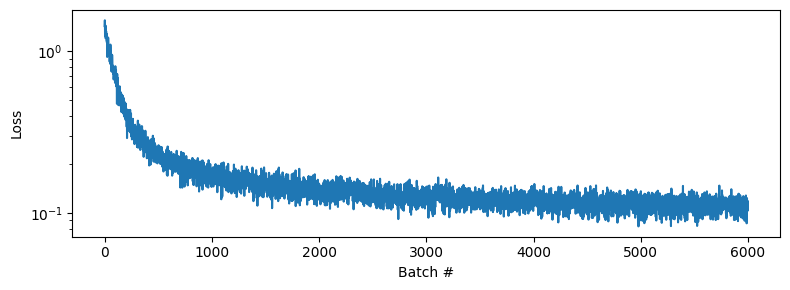

In [ ]:
# retrieve and plot training history
with open(log_file, 'r') as file:
    loaded_training_log = json.load(file)

plot_training_log(log=loaded_training_log)




## V. 3. The model itself

Usually, reloading the model would involve re-creating the same model, and applying the trained weights to that model again. To re-create the model, one could re-use the same function as was used to create the original model (that's what we will do here), or one could exploit the configuration file we saved and re-loaded above to recreate a model exhaustively. The latter method might be more tedious to implement but has the benefit of being more exhaustive on the long run.


In [ ]:

env2 = mn.environment.RandomTargetReach(effector=mn.effector.ReluPointMass24(), max_ep_duration=1.)
policy2 = Policy(env.observation_space.shape[0], 32, env.n_muscles, device=device)

policy2.load_state_dict(th.load(weight_file))


<All keys matched successfully>


# VI. Evaluating the loaded model

We can then do a forward pass the loaded model like we did on the original model.



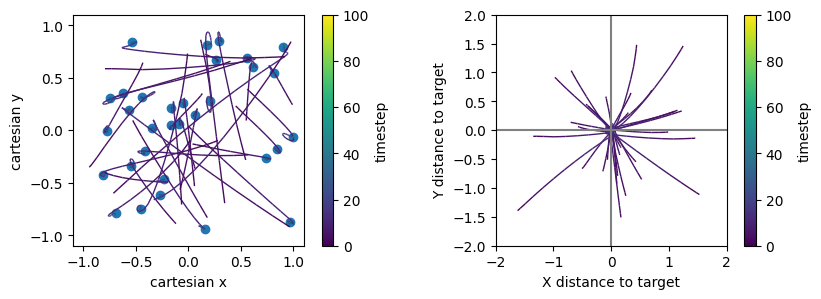

In [ ]:
# ==========
# Evaluation
# ==========

# initialize batch
h = policy.init_hidden(batch_size=batch_size)
obs, info = env.reset(options={"batch_size": batch_size})
terminated = False

# initial positions and targets
xy = [info["states"]["fingertip"][:, None, :]]
tg = [info["goal"][:, None, :]]

# simulate whole episode
while not terminated:  # will run until `max_ep_duration` is reached
  action, h = policy(obs, h)
  obs, reward, terminated, truncated, info = env.step(action=action)

  xy.append(info["states"]["fingertip"][:, None, :])  # trajectories
  tg.append(info["goal"][:, None, :])  # targets

# concatenate into a (batch_size, n_timesteps, xy) tensor
xy = th.detach(th.cat(xy, axis=1))
tg = th.detach(th.cat(tg, axis=1))

plot_simulations(xy=xy, target_xy=tg)


# VIII. Feedback-Driven Plasticity Experiment

This section replaces the GRU controller with a simple recurrent neural network that includes an explicit error-feedback pathway.

The model will first be trained using BPTT. After baseline training, all parameters will be frozen except the recurrent weights, which will be adapted using a local feedback-driven plasticity rule.

## Experimental protocol

We follow a two-stage training procedure inspired by Feulner et al. (Nature Communications, 2025).

### Phase 1 – Baseline training

A recurrent neural network controller is trained using standard backpropagation through time (BPTT) on the reaching task until stable performance is achieved.

### Phase 2 – Feedback-driven adaptation

The trained controller is exposed to a visuomotor perturbation. During adaptation:

- input weights remain fixed
- output weights remain fixed
- feedback weights remain fixed
- only recurrent connections are modified
- updates are computed locally from delayed error feedback and recurrent activity
- no gradient backpropagation is used

Performance is evaluated before perturbation, during perturbation, after adaptation, and during washout.

In [ ]:
def rotate_position(position, origin, angle_degrees):
    """
    Rotate 2-D positions around a specified origin.

    Parameters
    ----------
    position : torch.Tensor
        Shape: (batch_size, 2)

    origin : torch.Tensor
        Shape: (batch_size, 2)

    angle_degrees : float
        Counterclockwise rotation angle in degrees.

    Returns
    -------
    torch.Tensor
        Rotated positions with shape (batch_size, 2).
    """

    angle_radians = th.tensor(
        np.deg2rad(angle_degrees),
        device=position.device,
        dtype=position.dtype,
    )

    cos_angle = th.cos(angle_radians)
    sin_angle = th.sin(angle_radians)

    rotation_matrix = th.stack([
        th.stack([cos_angle, -sin_angle]),
        th.stack([sin_angle,  cos_angle]),
    ])

    displacement = position - origin
    rotated_displacement = displacement @ rotation_matrix.T

    return origin + rotated_displacement

In [ ]:
import copy
import math
import random
from collections import deque

import numpy as np
import torch as th


class FeedbackRNNPolicy(th.nn.Module):
    """
    Continuous-time recurrent controller for MotorNet.

    The controller has:
      - observation input pathway
      - recurrent pathway
      - delayed 2-D visual-error feedback pathway
      - muscle activation output pathway

    Only the recurrent weight matrix will be modified during
    feedback-driven adaptation.
    """

    def __init__(
        self,
        input_dim: int,
        hidden_dim: int,
        output_dim: int,
        device,
        dt: float,
        tau: float = 0.05,
        feedback_delay_seconds: float = 0.12,
    ):
        super().__init__()

        self.device = th.device(device)

        self.input_dim = int(input_dim)
        self.hidden_dim = int(hidden_dim)
        self.output_dim = int(output_dim)

        self.dt = float(dt)
        self.tau = float(tau)

        if self.dt <= 0:
            raise ValueError("dt must be positive.")

        if self.tau <= 0:
            raise ValueError("tau must be positive.")

        self.alpha = self.dt / self.tau

        if not 0.0 < self.alpha <= 1.0:
            raise ValueError(
                f"Expected 0 < dt/tau <= 1, but got alpha={self.alpha:.4f}."
            )

        self.feedback_delay_seconds = float(
            feedback_delay_seconds
        )

        self.feedback_delay_steps = max(
            0,
            int(
                round(
                    self.feedback_delay_seconds
                    / self.dt
                )
            ),
        )

        # Observation -> recurrent population
        self.input_layer = th.nn.Linear(
            self.input_dim,
            self.hidden_dim,
            bias=True,
        )

        # Recurrent population -> recurrent population
        self.recurrent_layer = th.nn.Linear(
            self.hidden_dim,
            self.hidden_dim,
            bias=False,
        )

        # Delayed 2-D visual position error -> recurrent population
        self.feedback_layer = th.nn.Linear(
            2,
            self.hidden_dim,
            bias=True,
        )

        # Recurrent population -> muscle activations
        self.output_layer = th.nn.Linear(
            self.hidden_dim,
            self.output_dim,
            bias=True,
        )

        self.activation = th.nn.ReLU()
        self.output_activation = th.nn.Sigmoid()

        self.reset_parameters()
        self.to(self.device)

    def reset_parameters(self):
        """
        Stable initialization suitable for MotorNet training.
        """

        th.nn.init.xavier_uniform_(
            self.input_layer.weight
        )
        th.nn.init.zeros_(
            self.input_layer.bias
        )

        th.nn.init.orthogonal_(
            self.recurrent_layer.weight
        )

        # Start feedback at a moderate scale.
        th.nn.init.xavier_uniform_(
            self.feedback_layer.weight,
            gain=0.25,
        )
        th.nn.init.zeros_(
            self.feedback_layer.bias
        )

        th.nn.init.xavier_uniform_(
            self.output_layer.weight
        )

        # Low initial muscle activation.
        th.nn.init.constant_(
            self.output_layer.bias,
            -5.0,
        )

    def init_hidden(
        self,
        batch_size: int,
    ):
        """
        Create recurrent state and delayed-error buffer.
        """

        batch_size = int(batch_size)

        dtype = next(
            self.parameters()
        ).dtype

        x = th.zeros(
            batch_size,
            self.hidden_dim,
            device=self.device,
            dtype=dtype,
        )

        r = self.activation(x)

        error_buffer = deque(
            [
                th.zeros(
                    batch_size,
                    2,
                    device=self.device,
                    dtype=dtype,
                )
                for _ in range(
                    self.feedback_delay_steps + 1
                )
            ],
            maxlen=self.feedback_delay_steps + 1,
        )

        return {
            "x": x,
            "r": r,
            "current_error": th.zeros(
                batch_size,
                2,
                device=self.device,
                dtype=dtype,
            ),
            "delayed_error": th.zeros(
                batch_size,
                2,
                device=self.device,
                dtype=dtype,
            ),
            "feedback_drive": th.zeros(
                batch_size,
                self.hidden_dim,
                device=self.device,
                dtype=dtype,
            ),
            "error_buffer": error_buffer,
            "feedback_enabled": True,
        }

    def set_feedback_error(
        self,
        h,
        visual_error: th.Tensor,
    ):
        """
        Store the current 2-D visual error.

        visual_error must be:
            desired_cursor_position - perceived_cursor_position
        """

        visual_error = visual_error.to(
            device=self.device,
            dtype=h["x"].dtype,
        )

        expected_shape = (
            h["x"].shape[0],
            2,
        )

        if visual_error.shape != expected_shape:
            raise ValueError(
                "visual_error has shape "
                f"{tuple(visual_error.shape)}, "
                f"expected {expected_shape}."
            )

        if not h["feedback_enabled"]:
            visual_error = th.zeros_like(
                visual_error
            )

        h["current_error"] = visual_error

        return h

    def forward(
        self,
        obs: th.Tensor,
        h,
    ):
        """
        Perform one controller timestep.
        """

        obs = obs.to(
            device=self.device,
            dtype=h["x"].dtype,
        )

        x = h["x"]
        r = h["r"]

        # Push current error into the delay line.
        h["error_buffer"].append(
            h["current_error"]
        )

        # Oldest error is the delayed visual error.
        delayed_error = h["error_buffer"][0]

        feedback_drive = self.feedback_layer(
            delayed_error
        )

        recurrent_input = (
            self.input_layer(obs)
            + self.recurrent_layer(r)
            + feedback_drive
        )

        x_new = (
            x
            + self.alpha
            * (
                -x
                + recurrent_input
            )
        )

        r_new = self.activation(
            x_new
        )

        action = self.output_activation(
            self.output_layer(r_new)
        )

        h["x"] = x_new
        h["r"] = r_new
        h["delayed_error"] = delayed_error
        h["feedback_drive"] = feedback_drive

        return action, h


print("FeedbackRNNPolicy class defined successfully.")

FeedbackRNNPolicy class defined successfully.


In [ ]:
obs, info = env.reset()

print(type(obs))
print(obs.shape)

print(obs)

<class 'torch.Tensor'>
torch.Size([1, 12])
tensor([[-0.2844,  0.9487, -0.9639,  0.5240,  3.3111,  1.8033,  3.8930,  2.7284,
          0.0000,  0.0000,  0.0000,  0.0000]])


In [ ]:
action = th.zeros(
    1,
    env.n_muscles,
    device=device,
)

obs2, reward, terminated, truncated, info = env.step(action)

print(obs2.shape)
print(obs2)

torch.Size([1, 12])
tensor([[-0.0191, -0.9629, -0.2534,  0.1010,  2.9469,  2.5800,  3.0809,  2.7322,
          0.0000,  0.0000,  0.0000,  0.0000]])


In [ ]:
def preprocess_feedback_observation(obs: th.Tensor) -> th.Tensor:
    """
    Prepare the MotorNet observation for the feedback RNN.

    MotorNet RandomTargetReach observation:
        obs[:, 0:2]  = target position
        obs[:, 2:4]  = fingertip / visual position
        obs[:, 4:8]  = muscle lengths
        obs[:, 8:12] = muscle velocities

    We remove the direct visual fingertip coordinates because visual
    position error is supplied separately through the delayed feedback
    pathway. This prevents unrotated visual information from bypassing
    the visuomotor feedback manipulation.
    """

    if obs.ndim != 2:
        raise ValueError(
            f"Expected observation shape [batch, features], got {tuple(obs.shape)}."
        )

    if obs.shape[-1] != 12:
        raise ValueError(
            f"Expected 12 MotorNet observation features, got {obs.shape[-1]}."
        )

    obs_processed = obs.clone()

    # Remove direct visual cursor input.
    obs_processed[:, 2:4] = 0.0

    return obs_processed


# Quick validation
obs, info = env.reset()

obs_processed = preprocess_feedback_observation(obs)

print("Raw observation:")
print(obs)

print("\nProcessed observation:")
print(obs_processed)

print("\nTarget retained:")
print(obs_processed[:, 0:2])

print("\nDirect visual cursor removed:")
print(obs_processed[:, 2:4])

print("\nProprioception retained:")
print(obs_processed[:, 4:12])

Raw observation:
tensor([[ 0.9544, -0.8133, -0.0199,  0.0775,  2.7886,  2.7598,  2.8976,  2.8699,
          0.0000,  0.0000,  0.0000,  0.0000]])

Processed observation:
tensor([[ 0.9544, -0.8133,  0.0000,  0.0000,  2.7886,  2.7598,  2.8976,  2.8699,
          0.0000,  0.0000,  0.0000,  0.0000]])

Target retained:
tensor([[ 0.9544, -0.8133]])

Direct visual cursor removed:
tensor([[0., 0.]])

Proprioception retained:
tensor([[2.7886, 2.7598, 2.8976, 2.8699, 0.0000, 0.0000, 0.0000, 0.0000]])


In [ ]:
# ============================================================
# STEP 3: CREATE AND SMOKE-TEST THE FEEDBACK RNN
# ============================================================

# MotorNet timestep
env_dt = float(env.dt)

input_dim = env.observation_space.shape[0]   # 12
hidden_dim = 128
output_dim = env.n_muscles

feedback_policy = FeedbackRNNPolicy(
    input_dim=input_dim,
    hidden_dim=hidden_dim,
    output_dim=output_dim,
    device=device,
    dt=env_dt,
    tau=0.05,
    feedback_delay_seconds=0.12,
)

# Reset MotorNet
obs, info = env.reset()

batch_size = obs.shape[0]

# Initialize recurrent state
h = feedback_policy.init_hidden(batch_size)

# Remove direct cursor input
obs_processed = preprocess_feedback_observation(obs)

# At the initial timestep, use zero visual error for this smoke test
zero_error = th.zeros(
    batch_size,
    2,
    device=device,
    dtype=obs.dtype,
)

h = feedback_policy.set_feedback_error(
    h,
    zero_error,
)

# One controller step
action, h = feedback_policy(
    obs_processed,
    h,
)

n_parameters = sum(
    parameter.numel()
    for parameter in feedback_policy.parameters()
)

print("Environment dt:", env_dt)
print("RNN tau:", feedback_policy.tau)
print("RNN alpha = dt/tau:", feedback_policy.alpha)
print(
    "Feedback delay steps:",
    feedback_policy.feedback_delay_steps,
)
print(
    "Effective feedback delay:",
    feedback_policy.feedback_delay_steps * env_dt,
    "seconds",
)

print("\nController dimensions")
print("Input dimension:", input_dim)
print("Hidden dimension:", hidden_dim)
print("Output dimension:", output_dim)
print("Number of parameters:", n_parameters)

print("\nSmoke-test tensors")
print("Processed observation shape:", obs_processed.shape)
print("Action shape:", action.shape)
print("Neural state x shape:", h["x"].shape)
print("Neural rate r shape:", h["r"].shape)
print("Delayed error shape:", h["delayed_error"].shape)
print("Feedback drive shape:", h["feedback_drive"].shape)

print("\nInitial action")
print(action)

assert action.shape == (batch_size, env.n_muscles)
assert th.isfinite(action).all()
assert th.all(action >= 0.0)
assert th.all(action <= 1.0)

print("\nController smoke test passed.")

Environment dt: 0.01
RNN tau: 0.05
RNN alpha = dt/tau: 0.19999999999999998
Feedback delay steps: 12
Effective feedback delay: 0.12 seconds

Controller dimensions
Input dimension: 12
Hidden dimension: 128
Output dimension: 4
Number of parameters: 18948

Smoke-test tensors
Processed observation shape: torch.Size([1, 12])
Action shape: torch.Size([1, 4])
Neural state x shape: torch.Size([1, 128])
Neural rate r shape: torch.Size([1, 128])
Delayed error shape: torch.Size([1, 2])
Feedback drive shape: torch.Size([1, 128])

Initial action
tensor([[0.0073, 0.0094, 0.0071, 0.0080]], grad_fn=<SigmoidBackward0>)

Controller smoke test passed.


In [ ]:
# ============================================================
# STEP 4: DESIRED MINIMUM-JERK TRAJECTORY
# ============================================================

def minimum_jerk_trajectory(
    start_position: th.Tensor,
    target_position: th.Tensor,
    n_steps: int,
    device=None,
) -> th.Tensor:
    """
    Construct a smooth minimum-jerk Cartesian trajectory.

    Parameters
    ----------
    start_position
        Tensor of shape [batch_size, 2].

    target_position
        Tensor of shape [batch_size, 2].

    n_steps
        Number of environment transitions in the episode.

    Returns
    -------
    desired_position
        Tensor of shape [batch_size, n_steps + 1, 2].

        Index 0 is the initial position.
        Index n_steps is the target position.
    """

    if start_position.ndim != 2 or start_position.shape[-1] != 2:
        raise ValueError(
            "start_position must have shape [batch_size, 2], "
            f"but received {tuple(start_position.shape)}."
        )

    if target_position.shape != start_position.shape:
        raise ValueError(
            "target_position must have the same shape as "
            f"start_position. Received {tuple(target_position.shape)} "
            f"and {tuple(start_position.shape)}."
        )

    if n_steps < 1:
        raise ValueError("n_steps must be at least 1.")

    if device is None:
        device = start_position.device

    dtype = start_position.dtype

    # Normalized movement time: 0 -> 1.
    s = th.linspace(
        0.0,
        1.0,
        n_steps + 1,
        device=device,
        dtype=dtype,
    )

    # Minimum-jerk interpolation coefficient.
    blend = (
        10.0 * s**3
        - 15.0 * s**4
        + 6.0 * s**5
    )

    displacement = (
        target_position
        - start_position
    )

    desired_position = (
        start_position[:, None, :]
        + blend[None, :, None]
        * displacement[:, None, :]
    )

    return desired_position


# ------------------------------------------------------------
# Determine the number of environment transitions
# ------------------------------------------------------------

episode_duration = float(env.max_ep_duration)
env_dt = float(env.dt)

n_episode_steps = int(
    round(episode_duration / env_dt)
)

# ------------------------------------------------------------
# Test the trajectory function
# ------------------------------------------------------------

obs, info = env.reset(
    options={"batch_size": 4}
)

start_position = info["states"]["fingertip"].clone()
target_position = info["goal"].clone()

desired_position = minimum_jerk_trajectory(
    start_position=start_position,
    target_position=target_position,
    n_steps=n_episode_steps,
    device=device,
)

print("Episode duration:", episode_duration)
print("Environment dt:", env_dt)
print("Number of transitions:", n_episode_steps)

print("\nTrajectory shape:")
print(desired_position.shape)

print("\nStart-position error:")
print(
    th.max(
        th.abs(
            desired_position[:, 0, :]
            - start_position
        )
    ).item()
)

print("\nTarget-position error:")
print(
    th.max(
        th.abs(
            desired_position[:, -1, :]
            - target_position
        )
    ).item()
)

print("\nExample trial")
print("Start: ", start_position[0])
print("Middle:", desired_position[0, n_episode_steps // 2])
print("Target:", desired_position[0, -1])

assert desired_position.shape == (
    4,
    n_episode_steps + 1,
    2,
)

assert th.allclose(
    desired_position[:, 0, :],
    start_position,
    atol=1e-6,
)

assert th.allclose(
    desired_position[:, -1, :],
    target_position,
    atol=1e-5,
)

print("\nMinimum-jerk trajectory test passed.")

Episode duration: 1.0
Environment dt: 0.01
Number of transitions: 100

Trajectory shape:
torch.Size([4, 101, 2])

Start-position error:
0.0

Target-position error:
0.0

Example trial
Start:  tensor([-0.0042, -0.8835])
Middle: tensor([ 0.0210, -0.8224])
Target: tensor([ 0.0461, -0.7613])

Minimum-jerk trajectory test passed.


In [ ]:
# ============================================================
# STEP 5: DIFFERENTIABLE MOTORN﻿ET ROLLOUT
# ============================================================

def preprocess_feedback_observation(obs: th.Tensor) -> th.Tensor:
    """
    Current baseline preprocessing.

    For initial controller training, preserve the complete MotorNet
    observation. During visuomotor rotation, the cursor-related entries
    must later be transformed consistently with the displayed cursor.
    """
    if obs.ndim != 2:
        raise ValueError(
            f"Expected [batch, features], got {tuple(obs.shape)}."
        )

    if obs.shape[-1] != 12:
        raise ValueError(
            f"Expected 12 observation features, got {obs.shape[-1]}."
        )

    return obs


def rollout_feedback_controller(
    env,
    policy,
    batch_size: int,
    feedback_enabled: bool = True,
):
    """
    Run one complete differentiable MotorNet episode.

    Returns a dictionary containing:
      hand_position:    [batch, time, 2]
      desired_position: [batch, time, 2]
      target_position:  [batch, time, 2]
      actions:          [batch, transitions, n_muscles]
      visual_errors:    [batch, transitions, 2]
      neural_rates:     [batch, transitions, hidden_dim]
    """

    obs, info = env.reset(
        options={"batch_size": int(batch_size)}
    )

    obs = obs.to(policy.device)

    start_position = (
        info["states"]["fingertip"]
        .to(policy.device)
        .clone()
    )

    goal_position = (
        info["goal"]
        .to(policy.device)
        .clone()
    )

    desired_position = minimum_jerk_trajectory(
        start_position=start_position,
        target_position=goal_position,
        n_steps=n_episode_steps,
        device=policy.device,
    )

    h = policy.init_hidden(batch_size)
    h["feedback_enabled"] = bool(feedback_enabled)

    hand_positions = [start_position[:, None, :]]
    target_positions = [goal_position[:, None, :]]

    actions = []
    visual_errors = []
    neural_rates = []

    terminated = False
    step = 0

    while not terminated:
        if step >= n_episode_steps:
            raise RuntimeError(
                "Environment did not terminate after the expected "
                f"{n_episode_steps} transitions."
            )

        current_hand_position = (
            info["states"]["fingertip"]
            .to(policy.device)
        )

        current_desired_position = desired_position[:, step, :]

        # Positive error means the displayed hand is behind the desired
        # trajectory in that Cartesian direction.
        current_visual_error = (
            current_desired_position
            - current_hand_position
        )

        h = policy.set_feedback_error(
            h=h,
            visual_error=current_visual_error,
        )

        policy_input = preprocess_feedback_observation(obs)

        action, h = policy(
            policy_input,
            h,
        )

        obs, reward, terminated, truncated, info = env.step(
            action=action
        )

        obs = obs.to(policy.device)

        next_hand_position = (
            info["states"]["fingertip"]
            .to(policy.device)
        )

        hand_positions.append(
            next_hand_position[:, None, :]
        )

        target_positions.append(
            goal_position[:, None, :]
        )

        actions.append(action[:, None, :])
        visual_errors.append(
            current_visual_error[:, None, :]
        )
        neural_rates.append(
            h["r"][:, None, :]
        )

        step += 1

    hand_positions = th.cat(hand_positions, dim=1)
    target_positions = th.cat(target_positions, dim=1)
    actions = th.cat(actions, dim=1)
    visual_errors = th.cat(visual_errors, dim=1)
    neural_rates = th.cat(neural_rates, dim=1)

    if hand_positions.shape[1] != desired_position.shape[1]:
        raise RuntimeError(
            "Trajectory length mismatch: "
            f"hand={hand_positions.shape[1]}, "
            f"desired={desired_position.shape[1]}."
        )

    return {
        "hand_position": hand_positions,
        "desired_position": desired_position,
        "target_position": target_positions,
        "actions": actions,
        "visual_errors": visual_errors,
        "neural_rates": neural_rates,
    }


# ------------------------------------------------------------
# Smoke test: no training
# ------------------------------------------------------------

feedback_policy.eval()

test_rollout = rollout_feedback_controller(
    env=env,
    policy=feedback_policy,
    batch_size=4,
    feedback_enabled=True,
)

print("Hand position shape:")
print(test_rollout["hand_position"].shape)

print("\nDesired position shape:")
print(test_rollout["desired_position"].shape)

print("\nAction shape:")
print(test_rollout["actions"].shape)

print("\nVisual error shape:")
print(test_rollout["visual_errors"].shape)

print("\nNeural rates shape:")
print(test_rollout["neural_rates"].shape)

print("\nAll values finite:")
for key, value in test_rollout.items():
    print(key, bool(th.isfinite(value).all()))

print("\nInitial hand/desired mismatch:")
print(
    th.mean(
        th.linalg.vector_norm(
            test_rollout["hand_position"][:, 0, :]
            - test_rollout["desired_position"][:, 0, :],
            dim=-1,
        )
    ).item()
)

print("\nUntrained final endpoint error:")
print(
    th.mean(
        th.linalg.vector_norm(
            test_rollout["hand_position"][:, -1, :]
            - test_rollout["target_position"][:, -1, :],
            dim=-1,
        )
    ).item()
)

assert test_rollout["hand_position"].shape == (4, 101, 2)
assert test_rollout["desired_position"].shape == (4, 101, 2)
assert test_rollout["actions"].shape == (4, 100, env.n_muscles)
assert test_rollout["visual_errors"].shape == (4, 100, 2)
assert test_rollout["neural_rates"].shape == (
    4,
    100,
    feedback_policy.hidden_dim,
)

print("\nFull rollout smoke test passed.")

Hand position shape:
torch.Size([4, 101, 2])

Desired position shape:
torch.Size([4, 101, 2])

Action shape:
torch.Size([4, 100, 4])

Visual error shape:
torch.Size([4, 100, 2])

Neural rates shape:
torch.Size([4, 100, 128])

All values finite:
hand_position True
desired_position True
target_position True
actions True
visual_errors True
neural_rates True

Initial hand/desired mismatch:
0.0

Untrained final endpoint error:
1.5325703620910645

Full rollout smoke test passed.


In [ ]:
# ============================================================
# STEP 6: INSPECT CONTROLLER PARAMETERS
# ============================================================

print("Controller parameters:\n")

total_parameters = 0
trainable_parameters = 0

for name, parameter in feedback_policy.named_parameters():
    n = parameter.numel()

    total_parameters += n

    if parameter.requires_grad:
        trainable_parameters += n

    print(
        f"{name:35s} "
        f"shape={str(tuple(parameter.shape)):18s} "
        f"requires_grad={str(parameter.requires_grad):5s} "
        f"n={n}"
    )

print("\nParameter totals")
print("Total parameters:    ", total_parameters)
print("Trainable parameters:", trainable_parameters)

assert total_parameters == 18948
assert trainable_parameters == total_parameters

print("\nParameter inspection passed.")

Controller parameters:

input_layer.weight                  shape=(128, 12)          requires_grad=True  n=1536
input_layer.bias                    shape=(128,)             requires_grad=True  n=128
recurrent_layer.weight              shape=(128, 128)         requires_grad=True  n=16384
feedback_layer.weight               shape=(128, 2)           requires_grad=True  n=256
feedback_layer.bias                 shape=(128,)             requires_grad=True  n=128
output_layer.weight                 shape=(4, 128)           requires_grad=True  n=512
output_layer.bias                   shape=(4,)               requires_grad=True  n=4

Parameter totals
Total parameters:     18948
Trainable parameters: 18948

Parameter inspection passed.


In [ ]:
# ============================================================
# STEP 7: PARAMETER FREEZING FOR THE THREE TRAINING PHASES
# ============================================================

def set_controller_training_phase(
    policy: FeedbackRNNPolicy,
    phase: int,
) -> None:
    """
    Configure which controller parameters are trainable.

    Phase 1
    -------
    Train the ordinary controller while freezing the visual-error
    feedback pathway.

    Phase 2
    -------
    Train all pathways, including the visual-error feedback pathway.

    Phase 3
    -------
    Keep all pathways trainable. Random physical perturbations will
    be introduced later in the rollout function.

    Parameters
    ----------
    policy
        FeedbackRNNPolicy instance.

    phase
        Must be 1, 2, or 3.
    """

    if phase not in (1, 2, 3):
        raise ValueError(
            f"phase must be 1, 2, or 3; received {phase}."
        )

    # First freeze everything explicitly.
    for parameter in policy.parameters():
        parameter.requires_grad_(False)

    if phase == 1:
        # Ordinary controller pathways.
        for parameter in policy.input_layer.parameters():
            parameter.requires_grad_(True)

        for parameter in policy.recurrent_layer.parameters():
            parameter.requires_grad_(True)

        for parameter in policy.output_layer.parameters():
            parameter.requires_grad_(True)

        # feedback_layer remains frozen.

    elif phase in (2, 3):
        # All pathways are trainable.
        for parameter in policy.parameters():
            parameter.requires_grad_(True)


def print_trainable_parameters(
    policy: FeedbackRNNPolicy,
) -> None:
    """
    Print trainable and frozen controller parameters.
    """

    trainable_count = 0
    frozen_count = 0

    for name, parameter in policy.named_parameters():
        status = (
            "TRAINABLE"
            if parameter.requires_grad
            else "FROZEN"
        )

        print(f"{name:35s} {status}")

        if parameter.requires_grad:
            trainable_count += parameter.numel()
        else:
            frozen_count += parameter.numel()

    print("\nTrainable parameter count:", trainable_count)
    print("Frozen parameter count:   ", frozen_count)
    print("Total parameter count:    ", trainable_count + frozen_count)


# ------------------------------------------------------------
# Validate Phase 1
# ------------------------------------------------------------

print("PHASE 1")
print("-------")

set_controller_training_phase(
    feedback_policy,
    phase=1,
)

print_trainable_parameters(feedback_policy)

assert feedback_policy.input_layer.weight.requires_grad
assert feedback_policy.input_layer.bias.requires_grad

assert feedback_policy.recurrent_layer.weight.requires_grad

assert not feedback_policy.feedback_layer.weight.requires_grad
assert not feedback_policy.feedback_layer.bias.requires_grad

assert feedback_policy.output_layer.weight.requires_grad
assert feedback_policy.output_layer.bias.requires_grad


# ------------------------------------------------------------
# Validate Phase 2
# ------------------------------------------------------------

print("\n\nPHASE 2")
print("-------")

set_controller_training_phase(
    feedback_policy,
    phase=2,
)

print_trainable_parameters(feedback_policy)

assert all(
    parameter.requires_grad
    for parameter in feedback_policy.parameters()
)


# ------------------------------------------------------------
# Validate Phase 3
# ------------------------------------------------------------

print("\n\nPHASE 3")
print("-------")

set_controller_training_phase(
    feedback_policy,
    phase=3,
)

print_trainable_parameters(feedback_policy)

assert all(
    parameter.requires_grad
    for parameter in feedback_policy.parameters()
)

print("\nTraining-phase configuration test passed.")

PHASE 1
-------
input_layer.weight                  TRAINABLE
input_layer.bias                    TRAINABLE
recurrent_layer.weight              TRAINABLE
feedback_layer.weight               FROZEN
feedback_layer.bias                 FROZEN
output_layer.weight                 TRAINABLE
output_layer.bias                   TRAINABLE

Trainable parameter count: 18564
Frozen parameter count:    384
Total parameter count:     18948


PHASE 2
-------
input_layer.weight                  TRAINABLE
input_layer.bias                    TRAINABLE
recurrent_layer.weight              TRAINABLE
feedback_layer.weight               TRAINABLE
feedback_layer.bias                 TRAINABLE
output_layer.weight                 TRAINABLE
output_layer.bias                   TRAINABLE

Trainable parameter count: 18948
Frozen parameter count:    0
Total parameter count:     18948


PHASE 3
-------
input_layer.weight                  TRAINABLE
input_layer.bias                    TRAINABLE
recurrent_layer.weight  

In [ ]:
# ============================================================
# STEP 8: MOVEMENT LOSS
# ============================================================

def compute_feedback_controller_loss(
    rollout: dict,
    trajectory_weight: float = 1.0,
    endpoint_weight: float = 5.0,
    effort_weight: float = 1e-4,
    smoothness_weight: float = 1e-3,
) -> dict:
    """
    Compute the MotorNet controller-training loss.

    Parameters
    ----------
    rollout
        Output dictionary from rollout_feedback_controller().

    trajectory_weight
        Weight on mean squared Cartesian trajectory error.

    endpoint_weight
        Weight on final endpoint error.

    effort_weight
        Weight on squared muscle activations.

    smoothness_weight
        Weight on changes between consecutive muscle commands.

    Returns
    -------
    Dictionary containing the total loss and its individual components.
    """

    hand_position = rollout["hand_position"]
    desired_position = rollout["desired_position"]
    actions = rollout["actions"]

    if hand_position.shape != desired_position.shape:
        raise ValueError(
            "hand_position and desired_position must have identical "
            f"shapes, received {tuple(hand_position.shape)} and "
            f"{tuple(desired_position.shape)}."
        )

    if actions.ndim != 3:
        raise ValueError(
            "actions must have shape [batch, time, muscles], "
            f"received {tuple(actions.shape)}."
        )

    # --------------------------------------------------------
    # 1. Full-trajectory Cartesian tracking loss
    # --------------------------------------------------------

    position_error = hand_position - desired_position

    trajectory_loss = th.mean(
        th.sum(position_error**2, dim=-1)
    )

    # --------------------------------------------------------
    # 2. Final endpoint loss
    # --------------------------------------------------------

    endpoint_error = (
        hand_position[:, -1, :]
        - desired_position[:, -1, :]
    )

    endpoint_loss = th.mean(
        th.sum(endpoint_error**2, dim=-1)
    )

    # --------------------------------------------------------
    # 3. Muscle-effort regularization
    # --------------------------------------------------------

    effort_loss = th.mean(actions**2)

    # --------------------------------------------------------
    # 4. Action-smoothness regularization
    # --------------------------------------------------------

    if actions.shape[1] > 1:
        action_difference = (
            actions[:, 1:, :]
            - actions[:, :-1, :]
        )

        smoothness_loss = th.mean(
            action_difference**2
        )
    else:
        smoothness_loss = th.zeros(
            (),
            device=actions.device,
            dtype=actions.dtype,
        )

    # --------------------------------------------------------
    # Weighted total
    # --------------------------------------------------------

    total_loss = (
        trajectory_weight * trajectory_loss
        + endpoint_weight * endpoint_loss
        + effort_weight * effort_loss
        + smoothness_weight * smoothness_loss
    )

    # Useful physical metrics, not directly weighted into the loss.
    mean_trajectory_distance = th.mean(
        th.linalg.vector_norm(
            position_error,
            dim=-1,
        )
    )

    mean_endpoint_distance = th.mean(
        th.linalg.vector_norm(
            endpoint_error,
            dim=-1,
        )
    )

    return {
        "total": total_loss,
        "trajectory": trajectory_loss,
        "endpoint": endpoint_loss,
        "effort": effort_loss,
        "smoothness": smoothness_loss,
        "mean_trajectory_distance": mean_trajectory_distance,
        "mean_endpoint_distance": mean_endpoint_distance,
    }


# ------------------------------------------------------------
# Test the loss on the existing untrained rollout
# ------------------------------------------------------------

test_losses = compute_feedback_controller_loss(
    test_rollout
)

print("Untrained controller loss")
print("-------------------------")

for name, value in test_losses.items():
    print(f"{name:28s}: {value.item():.8f}")


# ------------------------------------------------------------
# Basic consistency tests
# ------------------------------------------------------------

assert test_losses["total"].ndim == 0
assert test_losses["total"].requires_grad

for name, value in test_losses.items():
    assert th.isfinite(value), f"{name} is not finite."
    assert value.item() >= 0.0, f"{name} is negative."

expected_total = (
    1.0 * test_losses["trajectory"]
    + 5.0 * test_losses["endpoint"]
    + 1e-4 * test_losses["effort"]
    + 1e-3 * test_losses["smoothness"]
)

assert th.allclose(
    test_losses["total"],
    expected_total,
)

print("\nMovement-loss test passed.")

Untrained controller loss
-------------------------
total                       : 12.84147644
trajectory                  : 1.02565920
endpoint                    : 2.36316347
effort                      : 0.00197178
smoothness                  : 0.00006416
mean_trajectory_distance    : 0.77977377
mean_endpoint_distance      : 1.53257036

Movement-loss test passed.


Epoch    1/300 | loss   9.97926 | traj_dist  0.6493 | endpoint_dist  1.2609 | grad 152.1903
Epoch   20/300 | loss   0.25915 | traj_dist  0.1284 | endpoint_dist  0.1875 | grad 15.9531
Epoch   40/300 | loss   0.09203 | traj_dist  0.1389 | endpoint_dist  0.0978 | grad 18.2384
Epoch   60/300 | loss   0.08288 | traj_dist  0.1189 | endpoint_dist  0.1024 | grad 17.2348
Epoch   80/300 | loss   0.03583 | traj_dist  0.0932 | endpoint_dist  0.0575 | grad  8.8365
Epoch  100/300 | loss   0.04019 | traj_dist  0.0701 | endpoint_dist  0.0750 | grad 12.5443
Epoch  120/300 | loss   0.01996 | traj_dist  0.0613 | endpoint_dist  0.0443 | grad  5.4809
Epoch  140/300 | loss   0.01790 | traj_dist  0.0529 | endpoint_dist  0.0449 | grad  4.0914
Epoch  160/300 | loss   0.05883 | traj_dist  0.0564 | endpoint_dist  0.1013 | grad 16.0922
Epoch  180/300 | loss   0.03901 | traj_dist  0.0510 | endpoint_dist  0.0793 | grad 11.2755
Epoch  200/300 | loss   0.03870 | traj_dist  0.0526 | endpoint_dist  0.0798 | grad 10.495

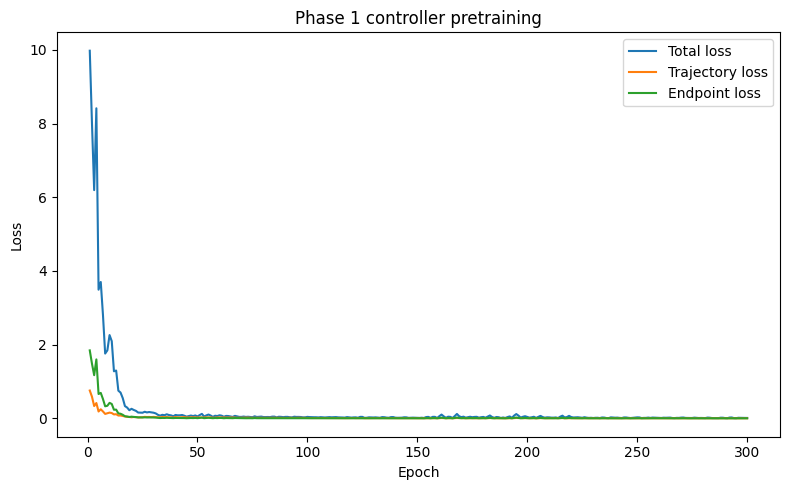

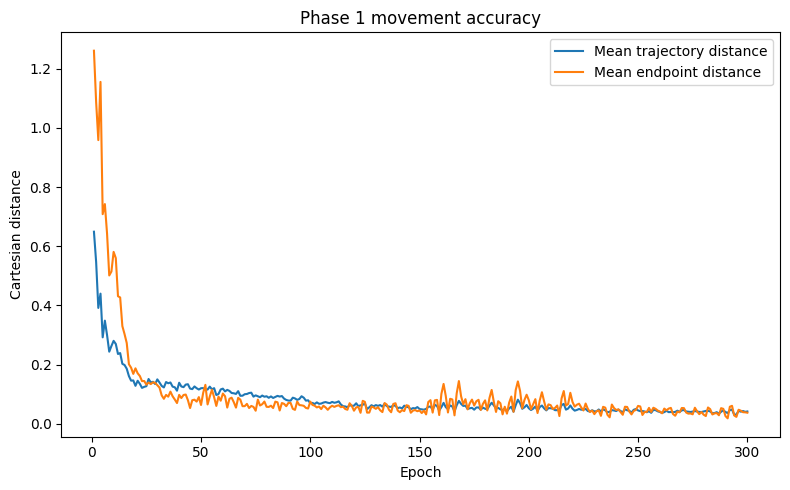

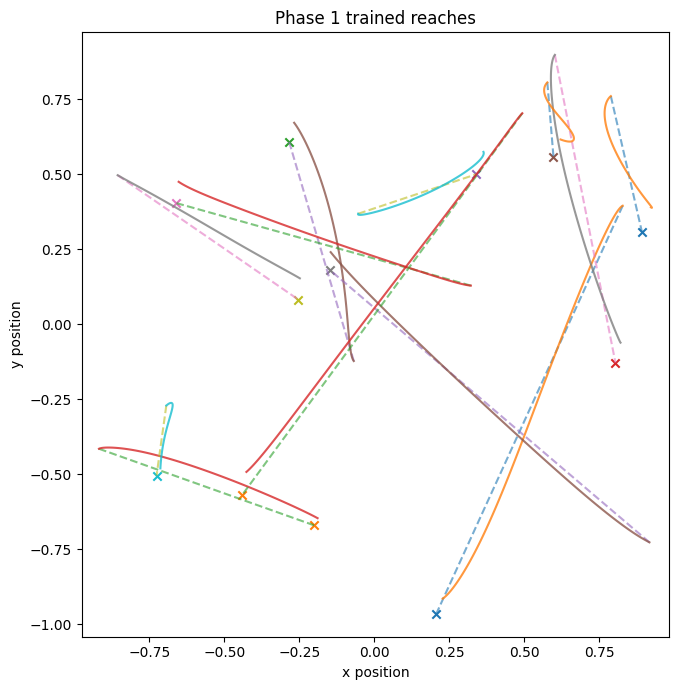

In [ ]:
# ============================================================
# STEP 9: PHASE 1 CONTROLLER PRETRAINING
# Feedback pathway frozen and disabled
# ============================================================

import copy
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Phase 1 settings
# ------------------------------------------------------------

phase1_epochs = 300
phase1_batch_size = 64
phase1_learning_rate = 1e-3
gradient_clip_norm = 1.0
print_every = 20


# ------------------------------------------------------------
# Configure the controller
# ------------------------------------------------------------

set_controller_training_phase(
    feedback_policy,
    phase=1,
)

feedback_policy.train()

phase1_optimizer = th.optim.Adam(
    [
        parameter
        for parameter in feedback_policy.parameters()
        if parameter.requires_grad
    ],
    lr=phase1_learning_rate,
)

phase1_history = {
    "total": [],
    "trajectory": [],
    "endpoint": [],
    "effort": [],
    "smoothness": [],
    "mean_trajectory_distance": [],
    "mean_endpoint_distance": [],
    "gradient_norm": [],
}

best_phase1_loss = float("inf")
best_phase1_state = None


# ------------------------------------------------------------
# Training loop
# ------------------------------------------------------------

for epoch in range(1, phase1_epochs + 1):

    phase1_optimizer.zero_grad(set_to_none=True)

    rollout = rollout_feedback_controller(
        env=env,
        policy=feedback_policy,
        batch_size=phase1_batch_size,

        # Phase 1 learns feedforward/recurrent motor control
        # without using the visual-error feedback pathway.
        feedback_enabled=False,
    )

    losses = compute_feedback_controller_loss(
        rollout=rollout,
        trajectory_weight=1.0,
        endpoint_weight=5.0,
        effort_weight=1e-4,
        smoothness_weight=1e-3,
    )

    losses["total"].backward()

    gradient_norm = th.nn.utils.clip_grad_norm_(
        [
            parameter
            for parameter in feedback_policy.parameters()
            if parameter.requires_grad
        ],
        max_norm=gradient_clip_norm,
    )

    if not th.isfinite(gradient_norm):
        raise RuntimeError(
            f"Non-finite gradient norm at epoch {epoch}: "
            f"{gradient_norm}"
        )

    phase1_optimizer.step()

    # --------------------------------------------------------
    # Logging
    # --------------------------------------------------------

    for name in (
        "total",
        "trajectory",
        "endpoint",
        "effort",
        "smoothness",
        "mean_trajectory_distance",
        "mean_endpoint_distance",
    ):
        phase1_history[name].append(
            float(losses[name].detach().cpu())
        )

    phase1_history["gradient_norm"].append(
        float(gradient_norm.detach().cpu())
    )

    current_loss = phase1_history["total"][-1]

    if current_loss < best_phase1_loss:
        best_phase1_loss = current_loss

        best_phase1_state = copy.deepcopy(
            feedback_policy.state_dict()
        )

    if epoch == 1 or epoch % print_every == 0:
        print(
            f"Epoch {epoch:4d}/{phase1_epochs} | "
            f"loss {phase1_history['total'][-1]:9.5f} | "
            f"traj_dist "
            f"{phase1_history['mean_trajectory_distance'][-1]:7.4f} | "
            f"endpoint_dist "
            f"{phase1_history['mean_endpoint_distance'][-1]:7.4f} | "
            f"grad {phase1_history['gradient_norm'][-1]:7.4f}"
        )


# ------------------------------------------------------------
# Restore the best Phase 1 checkpoint
# ------------------------------------------------------------

if best_phase1_state is None:
    raise RuntimeError("No valid Phase 1 checkpoint was produced.")

feedback_policy.load_state_dict(best_phase1_state)

print("\nPhase 1 training complete.")
print("Best Phase 1 loss:", best_phase1_loss)


# ------------------------------------------------------------
# Independent post-training evaluation
# ------------------------------------------------------------

feedback_policy.eval()

phase1_evaluation = rollout_feedback_controller(
    env=env,
    policy=feedback_policy,
    batch_size=128,
    feedback_enabled=False,
)

phase1_evaluation_losses = compute_feedback_controller_loss(
    phase1_evaluation
)

print("\nPhase 1 evaluation")
print("------------------")
print(
    "Mean trajectory distance:",
    phase1_evaluation_losses[
        "mean_trajectory_distance"
    ].item(),
)
print(
    "Mean endpoint distance:",
    phase1_evaluation_losses[
        "mean_endpoint_distance"
    ].item(),
)


# ------------------------------------------------------------
# Plot training curves
# ------------------------------------------------------------

epochs_axis = np.arange(
    1,
    len(phase1_history["total"]) + 1,
)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_axis,
    phase1_history["total"],
    label="Total loss",
)

plt.plot(
    epochs_axis,
    phase1_history["trajectory"],
    label="Trajectory loss",
)

plt.plot(
    epochs_axis,
    phase1_history["endpoint"],
    label="Endpoint loss",
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Phase 1 controller pretraining")
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))

plt.plot(
    epochs_axis,
    phase1_history["mean_trajectory_distance"],
    label="Mean trajectory distance",
)

plt.plot(
    epochs_axis,
    phase1_history["mean_endpoint_distance"],
    label="Mean endpoint distance",
)

plt.xlabel("Epoch")
plt.ylabel("Cartesian distance")
plt.title("Phase 1 movement accuracy")
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Visualize several trained reaches
# ------------------------------------------------------------

hand = (
    phase1_evaluation["hand_position"]
    .detach()
    .cpu()
    .numpy()
)

desired = (
    phase1_evaluation["desired_position"]
    .detach()
    .cpu()
    .numpy()
)

plt.figure(figsize=(7, 7))

n_plot_trials = min(12, hand.shape[0])

for trial in range(n_plot_trials):
    plt.plot(
        desired[trial, :, 0],
        desired[trial, :, 1],
        linestyle="--",
        alpha=0.6,
    )

    plt.plot(
        hand[trial, :, 0],
        hand[trial, :, 1],
        alpha=0.8,
    )

    plt.scatter(
        desired[trial, -1, 0],
        desired[trial, -1, 1],
        marker="x",
    )

plt.xlabel("x position")
plt.ylabel("y position")
plt.title("Phase 1 trained reaches")
plt.axis("equal")
plt.tight_layout()
plt.show()

Epoch    1/200 | loss   0.02321 | traj_dist  0.0458 | endpoint_dist  0.0611 | grad  9.1795
Epoch   20/200 | loss   0.00629 | traj_dist  0.0373 | endpoint_dist  0.0253 | grad  2.9388
Epoch   40/200 | loss   0.00535 | traj_dist  0.0324 | endpoint_dist  0.0234 | grad  1.3042
Epoch   60/200 | loss   0.00544 | traj_dist  0.0364 | endpoint_dist  0.0226 | grad  2.0263
Epoch   80/200 | loss   0.00350 | traj_dist  0.0325 | endpoint_dist  0.0165 | grad  1.0521
Epoch  100/200 | loss   0.00494 | traj_dist  0.0344 | endpoint_dist  0.0226 | grad  2.5483
Epoch  120/200 | loss   0.00348 | traj_dist  0.0327 | endpoint_dist  0.0170 | grad  1.4010
Epoch  140/200 | loss   0.00330 | traj_dist  0.0312 | endpoint_dist  0.0169 | grad  0.8738
Epoch  160/200 | loss   0.00342 | traj_dist  0.0304 | endpoint_dist  0.0178 | grad  1.7189
Epoch  180/200 | loss   0.00504 | traj_dist  0.0306 | endpoint_dist  0.0248 | grad  3.1945
Epoch  200/200 | loss   0.00489 | traj_dist  0.0292 | endpoint_dist  0.0249 | grad  3.5679

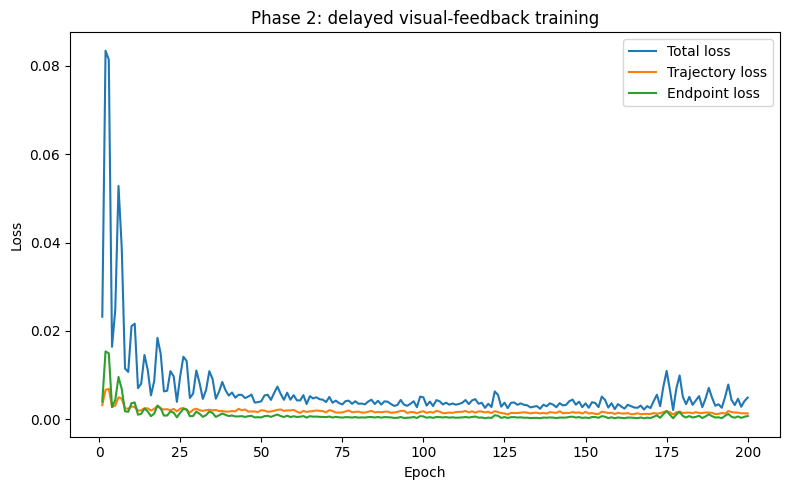

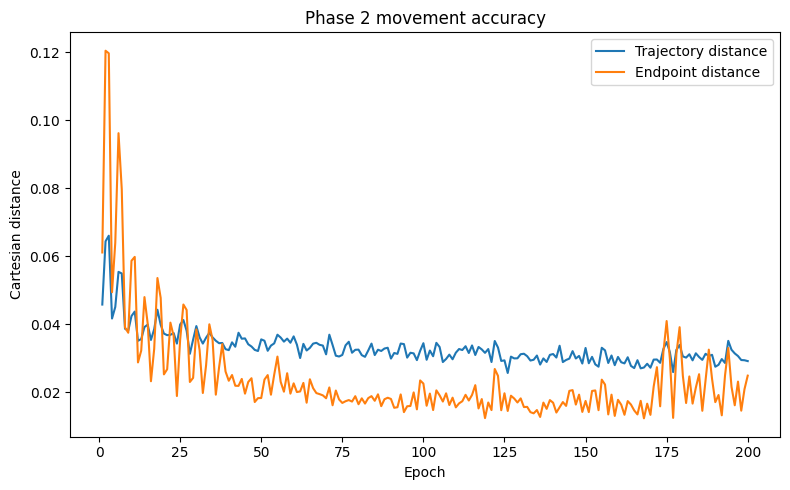

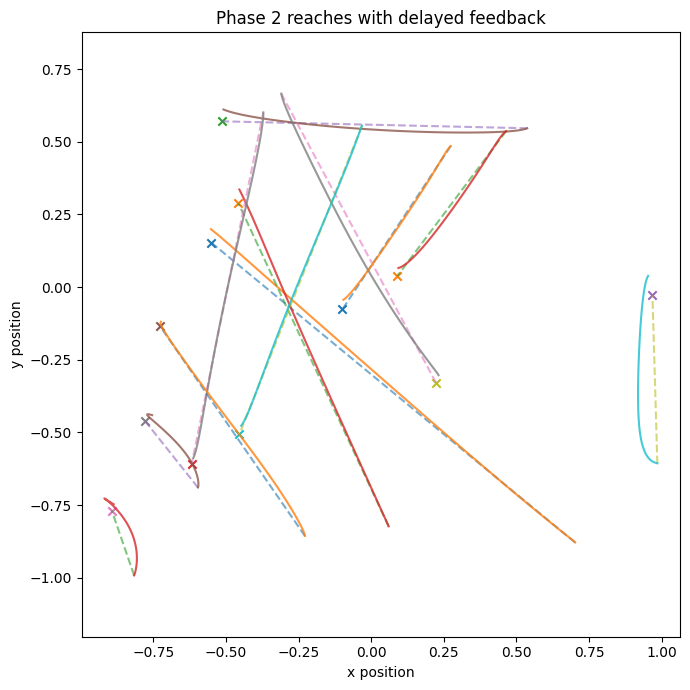

In [ ]:
# ============================================================
# STEP 10: PHASE 2 — TRAIN DELAYED VISUAL FEEDBACK
# ============================================================

import copy
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Phase 2 settings
# ------------------------------------------------------------

phase2_epochs = 200
phase2_batch_size = 64
phase2_learning_rate = 3e-4
phase2_gradient_clip = 1.0
phase2_print_every = 20


# ------------------------------------------------------------
# Enable all pathways
# ------------------------------------------------------------

set_controller_training_phase(
    feedback_policy,
    phase=2,
)

feedback_policy.train()

phase2_optimizer = th.optim.Adam(
    feedback_policy.parameters(),
    lr=phase2_learning_rate,
)

phase2_history = {
    "total": [],
    "trajectory": [],
    "endpoint": [],
    "mean_trajectory_distance": [],
    "mean_endpoint_distance": [],
    "gradient_norm": [],
}

best_phase2_loss = float("inf")
best_phase2_state = None


# ------------------------------------------------------------
# Phase 2 training
# ------------------------------------------------------------

for epoch in range(1, phase2_epochs + 1):

    phase2_optimizer.zero_grad(set_to_none=True)

    rollout = rollout_feedback_controller(
        env=env,
        policy=feedback_policy,
        batch_size=phase2_batch_size,
        feedback_enabled=True,
    )

    losses = compute_feedback_controller_loss(
        rollout=rollout,
        trajectory_weight=1.0,
        endpoint_weight=5.0,
        effort_weight=1e-4,
        smoothness_weight=1e-3,
    )

    losses["total"].backward()

    gradient_norm = th.nn.utils.clip_grad_norm_(
        feedback_policy.parameters(),
        max_norm=phase2_gradient_clip,
    )

    if not th.isfinite(gradient_norm):
        raise RuntimeError(
            f"Non-finite gradient norm at Phase 2 epoch {epoch}."
        )

    phase2_optimizer.step()

    for key in (
        "total",
        "trajectory",
        "endpoint",
        "mean_trajectory_distance",
        "mean_endpoint_distance",
    ):
        phase2_history[key].append(
            float(losses[key].detach().cpu())
        )

    phase2_history["gradient_norm"].append(
        float(gradient_norm.detach().cpu())
    )

    current_loss = phase2_history["total"][-1]

    if current_loss < best_phase2_loss:
        best_phase2_loss = current_loss
        best_phase2_state = copy.deepcopy(
            feedback_policy.state_dict()
        )

    if epoch == 1 or epoch % phase2_print_every == 0:
        print(
            f"Epoch {epoch:4d}/{phase2_epochs} | "
            f"loss {phase2_history['total'][-1]:9.5f} | "
            f"traj_dist "
            f"{phase2_history['mean_trajectory_distance'][-1]:7.4f} | "
            f"endpoint_dist "
            f"{phase2_history['mean_endpoint_distance'][-1]:7.4f} | "
            f"grad {phase2_history['gradient_norm'][-1]:7.4f}"
        )


# ------------------------------------------------------------
# Restore best Phase 2 checkpoint
# ------------------------------------------------------------

if best_phase2_state is None:
    raise RuntimeError("No valid Phase 2 checkpoint was produced.")

feedback_policy.load_state_dict(best_phase2_state)
feedback_policy.eval()

print("\nPhase 2 training complete.")
print("Best Phase 2 loss:", best_phase2_loss)


# ------------------------------------------------------------
# Evaluate with and without feedback
# Use separate batches because reset generates random targets.
# For a rough comparison, use a large evaluation batch.
# ------------------------------------------------------------

evaluation_batch_size = 256

evaluation_feedback_on = rollout_feedback_controller(
    env=env,
    policy=feedback_policy,
    batch_size=evaluation_batch_size,
    feedback_enabled=True,
)

losses_feedback_on = compute_feedback_controller_loss(
    evaluation_feedback_on
)

evaluation_feedback_off = rollout_feedback_controller(
    env=env,
    policy=feedback_policy,
    batch_size=evaluation_batch_size,
    feedback_enabled=False,
)

losses_feedback_off = compute_feedback_controller_loss(
    evaluation_feedback_off
)

print("\nPhase 2 evaluation")
print("------------------")

print("Feedback enabled")
print(
    "  Mean trajectory distance:",
    losses_feedback_on["mean_trajectory_distance"].item(),
)
print(
    "  Mean endpoint distance:  ",
    losses_feedback_on["mean_endpoint_distance"].item(),
)

print("\nFeedback disabled")
print(
    "  Mean trajectory distance:",
    losses_feedback_off["mean_trajectory_distance"].item(),
)
print(
    "  Mean endpoint distance:  ",
    losses_feedback_off["mean_endpoint_distance"].item(),
)


# ------------------------------------------------------------
# Inspect whether feedback weights changed
# ------------------------------------------------------------

feedback_weight_norm = (
    feedback_policy.feedback_layer.weight
    .detach()
    .norm()
    .item()
)

feedback_bias_norm = (
    feedback_policy.feedback_layer.bias
    .detach()
    .norm()
    .item()
)

print("\nFeedback pathway")
print("----------------")
print("Feedback weight norm:", feedback_weight_norm)
print("Feedback bias norm:  ", feedback_bias_norm)


# ------------------------------------------------------------
# Plot Phase 2 learning curves
# ------------------------------------------------------------

phase2_epoch_axis = np.arange(
    1,
    phase2_epochs + 1,
)

plt.figure(figsize=(8, 5))

plt.plot(
    phase2_epoch_axis,
    phase2_history["total"],
    label="Total loss",
)

plt.plot(
    phase2_epoch_axis,
    phase2_history["trajectory"],
    label="Trajectory loss",
)

plt.plot(
    phase2_epoch_axis,
    phase2_history["endpoint"],
    label="Endpoint loss",
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Phase 2: delayed visual-feedback training")
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))

plt.plot(
    phase2_epoch_axis,
    phase2_history["mean_trajectory_distance"],
    label="Trajectory distance",
)

plt.plot(
    phase2_epoch_axis,
    phase2_history["mean_endpoint_distance"],
    label="Endpoint distance",
)

plt.xlabel("Epoch")
plt.ylabel("Cartesian distance")
plt.title("Phase 2 movement accuracy")
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Plot example reaches with feedback
# ------------------------------------------------------------

hand = (
    evaluation_feedback_on["hand_position"]
    .detach()
    .cpu()
    .numpy()
)

desired = (
    evaluation_feedback_on["desired_position"]
    .detach()
    .cpu()
    .numpy()
)

plt.figure(figsize=(7, 7))

for trial in range(min(12, hand.shape[0])):

    plt.plot(
        desired[trial, :, 0],
        desired[trial, :, 1],
        linestyle="--",
        alpha=0.6,
    )

    plt.plot(
        hand[trial, :, 0],
        hand[trial, :, 1],
        alpha=0.8,
    )

    plt.scatter(
        desired[trial, -1, 0],
        desired[trial, -1, 1],
        marker="x",
    )

plt.xlabel("x position")
plt.ylabel("y position")
plt.title("Phase 2 reaches with delayed feedback")
plt.axis("equal")
plt.tight_layout()
plt.show()

Epoch    1/300 | loss   0.00671 | traj_dist  0.0316 | endpoint_dist  0.0306 | grad  4.1180
Epoch   20/300 | loss   0.00372 | traj_dist  0.0289 | endpoint_dist  0.0200 | grad  2.0072
Epoch   40/300 | loss   0.00388 | traj_dist  0.0314 | endpoint_dist  0.0188 | grad  1.5077
Epoch   60/300 | loss   0.00245 | traj_dist  0.0273 | endpoint_dist  0.0131 | grad  0.4943
Epoch   80/300 | loss   0.00267 | traj_dist  0.0302 | endpoint_dist  0.0130 | grad  0.8457
Epoch  100/300 | loss   0.00330 | traj_dist  0.0292 | endpoint_dist  0.0185 | grad  1.7508
Epoch  120/300 | loss   0.00285 | traj_dist  0.0260 | endpoint_dist  0.0173 | grad  1.8259
Epoch  140/300 | loss   0.00191 | traj_dist  0.0235 | endpoint_dist  0.0124 | grad  1.0995
Epoch  160/300 | loss   0.00194 | traj_dist  0.0260 | endpoint_dist  0.0117 | grad  0.6636
Epoch  180/300 | loss   0.00210 | traj_dist  0.0259 | endpoint_dist  0.0131 | grad  1.1530
Epoch  200/300 | loss   0.00250 | traj_dist  0.0254 | endpoint_dist  0.0160 | grad  1.7799

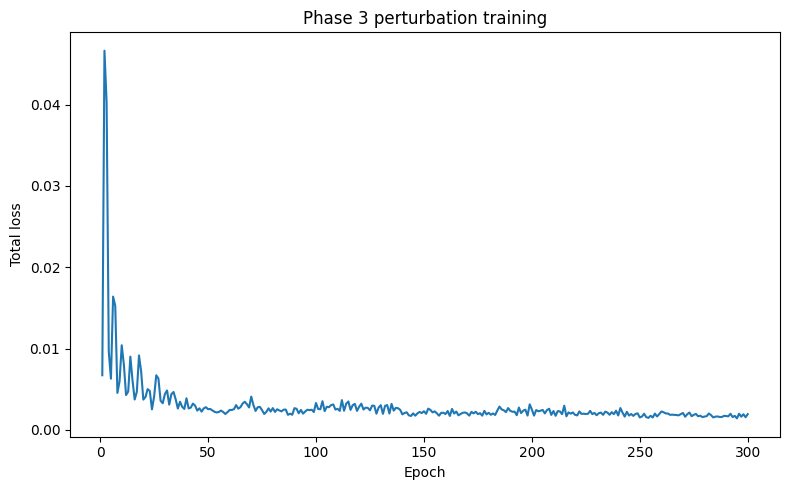

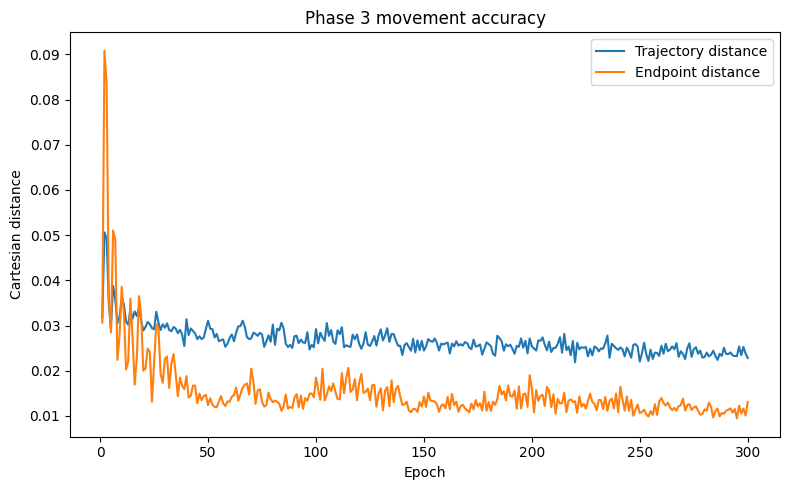

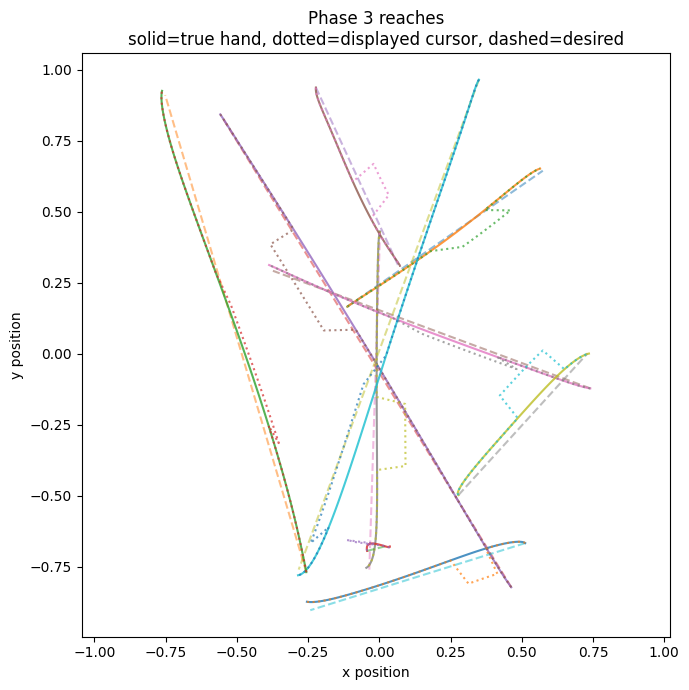

In [ ]:
# ============================================================
# STEP 11: PERTURBATION-AWARE ROLLOUT + PHASE 3 TRAINING
# ============================================================

import copy
import numpy as np
import matplotlib.pyplot as plt


def rollout_feedback_controller(
    env,
    policy,
    batch_size: int,
    feedback_enabled: bool = True,
    perturbation_probability: float = 0.0,
    perturbation_magnitude: float = 0.0,
    perturbation_start_range=(25, 55),
    perturbation_duration_range=(10, 25),
):
    """
    Run one differentiable MotorNet episode.

    Optional perturbation:
        A transient Cartesian offset is added to the displayed cursor.

    The perturbed displayed cursor is used consistently in:
        1. observation entries 2:4;
        2. the explicit delayed visual-error pathway.

    The physical fingertip itself is not changed.
    """

    obs, info = env.reset(
        options={"batch_size": int(batch_size)}
    )

    obs = obs.to(policy.device)

    start_position = (
        info["states"]["fingertip"]
        .to(policy.device)
        .clone()
    )

    goal_position = (
        info["goal"]
        .to(policy.device)
        .clone()
    )

    desired_position = minimum_jerk_trajectory(
        start_position=start_position,
        target_position=goal_position,
        n_steps=n_episode_steps,
        device=policy.device,
    )

    # --------------------------------------------------------
    # Generate one transient cursor perturbation per trial
    # --------------------------------------------------------

    perturbation_offsets = th.zeros(
        batch_size,
        n_episode_steps,
        2,
        device=policy.device,
        dtype=obs.dtype,
    )

    perturb_trial_mask = (
        th.rand(batch_size, device=policy.device)
        < perturbation_probability
    )

    for trial in range(batch_size):

        if not bool(perturb_trial_mask[trial]):
            continue

        start_step = int(
            th.randint(
                low=perturbation_start_range[0],
                high=perturbation_start_range[1] + 1,
                size=(1,),
                device=policy.device,
            ).item()
        )

        duration = int(
            th.randint(
                low=perturbation_duration_range[0],
                high=perturbation_duration_range[1] + 1,
                size=(1,),
                device=policy.device,
            ).item()
        )

        end_step = min(
            start_step + duration,
            n_episode_steps,
        )

        angle = (
            2.0
            * np.pi
            * th.rand(
                (),
                device=policy.device,
                dtype=obs.dtype,
            )
        )

        offset = perturbation_magnitude * th.stack(
            [
                th.cos(angle),
                th.sin(angle),
            ]
        )

        perturbation_offsets[
            trial,
            start_step:end_step,
            :
        ] = offset

    # --------------------------------------------------------
    # Recurrent rollout
    # --------------------------------------------------------

    h = policy.init_hidden(batch_size)
    h["feedback_enabled"] = bool(feedback_enabled)

    hand_positions = [start_position[:, None, :]]
    displayed_positions = [start_position[:, None, :]]
    target_positions = [goal_position[:, None, :]]

    actions = []
    visual_errors = []
    neural_rates = []

    terminated = False
    step = 0

    while not terminated:

        if step >= n_episode_steps:
            raise RuntimeError(
                "Environment exceeded expected episode length."
            )

        true_hand_position = (
            info["states"]["fingertip"]
            .to(policy.device)
        )

        cursor_offset = perturbation_offsets[:, step, :]

        displayed_hand_position = (
            true_hand_position
            + cursor_offset
        )

        current_desired_position = (
            desired_position[:, step, :]
        )

        current_visual_error = (
            current_desired_position
            - displayed_hand_position
        )

        h = policy.set_feedback_error(
            h=h,
            visual_error=current_visual_error,
        )

        # Replace MotorNet's true cursor entries with the displayed cursor.
        policy_input = obs.clone()

        policy_input[:, 2:4] = displayed_hand_position

        action, h = policy(
            policy_input,
            h,
        )

        obs, reward, terminated, truncated, info = env.step(
            action=action
        )

        obs = obs.to(policy.device)

        next_true_hand_position = (
            info["states"]["fingertip"]
            .to(policy.device)
        )

        # The perturbation for the next displayed sample.
        if step + 1 < n_episode_steps:
            next_offset = perturbation_offsets[:, step + 1, :]
        else:
            next_offset = th.zeros_like(next_true_hand_position)

        next_displayed_position = (
            next_true_hand_position
            + next_offset
        )

        hand_positions.append(
            next_true_hand_position[:, None, :]
        )

        displayed_positions.append(
            next_displayed_position[:, None, :]
        )

        target_positions.append(
            goal_position[:, None, :]
        )

        actions.append(action[:, None, :])

        visual_errors.append(
            current_visual_error[:, None, :]
        )

        neural_rates.append(
            h["r"][:, None, :]
        )

        step += 1

    return {
        "hand_position": th.cat(hand_positions, dim=1),
        "displayed_position": th.cat(displayed_positions, dim=1),
        "desired_position": desired_position,
        "target_position": th.cat(target_positions, dim=1),
        "actions": th.cat(actions, dim=1),
        "visual_errors": th.cat(visual_errors, dim=1),
        "neural_rates": th.cat(neural_rates, dim=1),
        "perturbation_offsets": perturbation_offsets,
        "perturbed_trial_mask": perturb_trial_mask,
    }


# ============================================================
# PHASE 3 TRAINING SETTINGS
# ============================================================

phase3_epochs = 300
phase3_batch_size = 64
phase3_learning_rate = 2e-4
phase3_gradient_clip = 1.0
phase3_print_every = 20

# Half of the movements receive a transient cursor perturbation.
phase3_perturbation_probability = 0.5

# Cartesian perturbation magnitude.
# Adjust later based on the scale of your workspace.
phase3_perturbation_magnitude = 0.10


set_controller_training_phase(
    feedback_policy,
    phase=3,
)

feedback_policy.train()

phase3_optimizer = th.optim.Adam(
    feedback_policy.parameters(),
    lr=phase3_learning_rate,
)

phase3_history = {
    "total": [],
    "trajectory_distance": [],
    "endpoint_distance": [],
    "gradient_norm": [],
}

best_phase3_loss = float("inf")
best_phase3_state = None


# ============================================================
# PHASE 3 TRAINING LOOP
# ============================================================

for epoch in range(1, phase3_epochs + 1):

    phase3_optimizer.zero_grad(set_to_none=True)

    rollout = rollout_feedback_controller(
        env=env,
        policy=feedback_policy,
        batch_size=phase3_batch_size,
        feedback_enabled=True,
        perturbation_probability=phase3_perturbation_probability,
        perturbation_magnitude=phase3_perturbation_magnitude,
        perturbation_start_range=(25, 55),
        perturbation_duration_range=(10, 25),
    )

    losses = compute_feedback_controller_loss(
        rollout=rollout,
        trajectory_weight=1.0,
        endpoint_weight=5.0,
        effort_weight=1e-4,
        smoothness_weight=1e-3,
    )

    losses["total"].backward()

    gradient_norm = th.nn.utils.clip_grad_norm_(
        feedback_policy.parameters(),
        max_norm=phase3_gradient_clip,
    )

    if not th.isfinite(gradient_norm):
        raise RuntimeError(
            f"Non-finite gradient norm at Phase 3 epoch {epoch}."
        )

    phase3_optimizer.step()

    phase3_history["total"].append(
        float(losses["total"].detach().cpu())
    )

    phase3_history["trajectory_distance"].append(
        float(
            losses["mean_trajectory_distance"]
            .detach()
            .cpu()
        )
    )

    phase3_history["endpoint_distance"].append(
        float(
            losses["mean_endpoint_distance"]
            .detach()
            .cpu()
        )
    )

    phase3_history["gradient_norm"].append(
        float(gradient_norm.detach().cpu())
    )

    current_loss = phase3_history["total"][-1]

    if current_loss < best_phase3_loss:
        best_phase3_loss = current_loss
        best_phase3_state = copy.deepcopy(
            feedback_policy.state_dict()
        )

    if epoch == 1 or epoch % phase3_print_every == 0:
        print(
            f"Epoch {epoch:4d}/{phase3_epochs} | "
            f"loss {current_loss:9.5f} | "
            f"traj_dist "
            f"{phase3_history['trajectory_distance'][-1]:7.4f} | "
            f"endpoint_dist "
            f"{phase3_history['endpoint_distance'][-1]:7.4f} | "
            f"grad "
            f"{phase3_history['gradient_norm'][-1]:7.4f}"
        )


if best_phase3_state is None:
    raise RuntimeError("No valid Phase 3 checkpoint produced.")

feedback_policy.load_state_dict(best_phase3_state)
feedback_policy.eval()

print("\nPhase 3 training complete.")
print("Best Phase 3 loss:", best_phase3_loss)


# ============================================================
# CONTROLLED EVALUATION
# ============================================================

evaluation_batch_size = 256

clean_evaluation = rollout_feedback_controller(
    env=env,
    policy=feedback_policy,
    batch_size=evaluation_batch_size,
    feedback_enabled=True,
    perturbation_probability=0.0,
    perturbation_magnitude=0.0,
)

perturbed_feedback_on = rollout_feedback_controller(
    env=env,
    policy=feedback_policy,
    batch_size=evaluation_batch_size,
    feedback_enabled=True,
    perturbation_probability=1.0,
    perturbation_magnitude=phase3_perturbation_magnitude,
)

perturbed_feedback_off = rollout_feedback_controller(
    env=env,
    policy=feedback_policy,
    batch_size=evaluation_batch_size,
    feedback_enabled=False,
    perturbation_probability=1.0,
    perturbation_magnitude=phase3_perturbation_magnitude,
)


clean_losses = compute_feedback_controller_loss(
    clean_evaluation
)

perturbed_on_losses = compute_feedback_controller_loss(
    perturbed_feedback_on
)

perturbed_off_losses = compute_feedback_controller_loss(
    perturbed_feedback_off
)


print("\nPhase 3 evaluation")
print("------------------")

print("Clean reaching")
print(
    "  Trajectory distance:",
    clean_losses["mean_trajectory_distance"].item(),
)
print(
    "  Endpoint distance:  ",
    clean_losses["mean_endpoint_distance"].item(),
)

print("\nPerturbation, feedback ON")
print(
    "  Trajectory distance:",
    perturbed_on_losses[
        "mean_trajectory_distance"
    ].item(),
)
print(
    "  Endpoint distance:  ",
    perturbed_on_losses[
        "mean_endpoint_distance"
    ].item(),
)

print("\nPerturbation, feedback OFF")
print(
    "  Trajectory distance:",
    perturbed_off_losses[
        "mean_trajectory_distance"
    ].item(),
)
print(
    "  Endpoint distance:  ",
    perturbed_off_losses[
        "mean_endpoint_distance"
    ].item(),
)


# ============================================================
# TRAINING CURVES
# ============================================================

epoch_axis = np.arange(1, phase3_epochs + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epoch_axis,
    phase3_history["total"],
)

plt.xlabel("Epoch")
plt.ylabel("Total loss")
plt.title("Phase 3 perturbation training")
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))

plt.plot(
    epoch_axis,
    phase3_history["trajectory_distance"],
    label="Trajectory distance",
)

plt.plot(
    epoch_axis,
    phase3_history["endpoint_distance"],
    label="Endpoint distance",
)

plt.xlabel("Epoch")
plt.ylabel("Cartesian distance")
plt.title("Phase 3 movement accuracy")
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# EXAMPLE PERTURBED REACHES
# ============================================================

true_hand = (
    perturbed_feedback_on["hand_position"]
    .detach()
    .cpu()
    .numpy()
)

displayed_hand = (
    perturbed_feedback_on["displayed_position"]
    .detach()
    .cpu()
    .numpy()
)

desired = (
    perturbed_feedback_on["desired_position"]
    .detach()
    .cpu()
    .numpy()
)

plt.figure(figsize=(7, 7))

for trial in range(min(10, true_hand.shape[0])):

    plt.plot(
        desired[trial, :, 0],
        desired[trial, :, 1],
        linestyle="--",
        alpha=0.5,
    )

    plt.plot(
        true_hand[trial, :, 0],
        true_hand[trial, :, 1],
        alpha=0.8,
    )

    plt.plot(
        displayed_hand[trial, :, 0],
        displayed_hand[trial, :, 1],
        linestyle=":",
        alpha=0.7,
    )

plt.xlabel("x position")
plt.ylabel("y position")
plt.title(
    "Phase 3 reaches\n"
    "solid=true hand, dotted=displayed cursor, dashed=desired"
)
plt.axis("equal")
plt.tight_layout()
plt.show()

Baseline
  Physical endpoint distance:  0.012527119368314743
  Displayed endpoint distance: 0.012527119368314743
  Physical angular error:      -0.03165024146437645 degrees
  Displayed angular error:     -0.03165024146437645 degrees

30-degree rotation, feedback ON
  Physical endpoint distance:  0.031083252280950546
  Displayed endpoint distance: 0.5360262393951416
  Physical angular error:      -0.8469667434692383 degrees
  Displayed angular error:     29.153034210205078 degrees

30-degree rotation, feedback OFF
  Physical endpoint distance:  0.037085726857185364
  Displayed endpoint distance: 0.52105712890625
  Physical angular error:      -0.9056267142295837 degrees
  Displayed angular error:     29.09437370300293 degrees

Washout
  Physical endpoint distance:  0.013488272204995155
  Displayed endpoint distance: 0.013488270342350006
  Physical angular error:      0.21129220724105835 degrees
  Displayed angular error:     0.21129220724105835 degrees


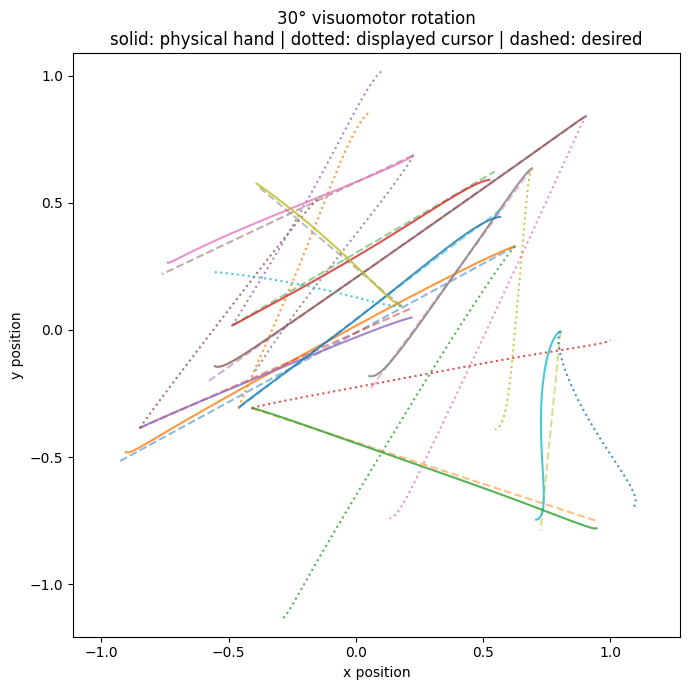

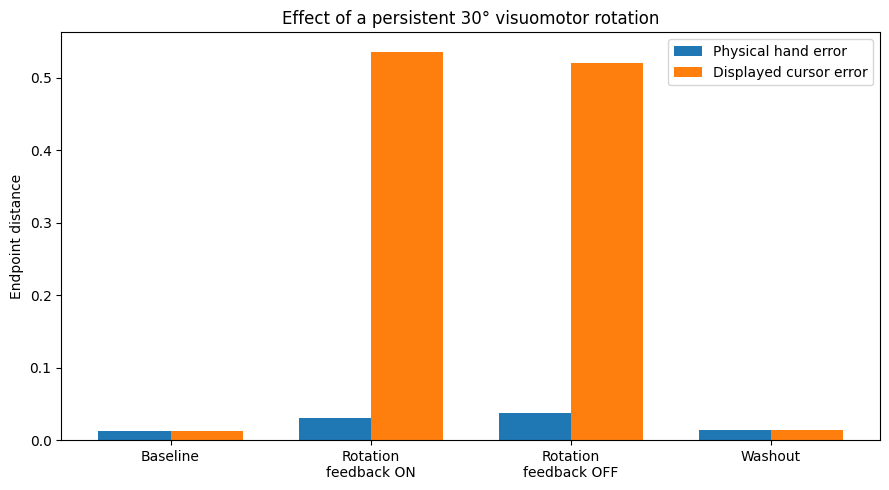

In [ ]:
# ============================================================
# STEP 12: PERSISTENT VISUOMOTOR ROTATION — NO PLASTICITY YET
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


def rotate_cursor_about_start(
    hand_position: th.Tensor,
    start_position: th.Tensor,
    rotation_degrees: float,
) -> th.Tensor:
    """
    Rotate the displayed cursor around the movement start position.

    hand_position:  [batch, 2]
    start_position: [batch, 2]
    """

    angle = th.tensor(
        np.deg2rad(rotation_degrees),
        device=hand_position.device,
        dtype=hand_position.dtype,
    )

    cos_angle = th.cos(angle)
    sin_angle = th.sin(angle)

    rotation_matrix = th.stack(
        [
            th.stack([cos_angle, -sin_angle]),
            th.stack([sin_angle,  cos_angle]),
        ]
    )

    relative_position = hand_position - start_position

    rotated_relative_position = (
        relative_position @ rotation_matrix.T
    )

    return start_position + rotated_relative_position


def rollout_visuomotor_rotation(
    env,
    policy,
    batch_size: int,
    rotation_degrees: float = 0.0,
    feedback_enabled: bool = True,
):
    """
    Run reaching trials under a constant visuomotor rotation.

    The controller sees the rotated cursor through:
      1. observation entries 2:4;
      2. delayed visual-error feedback.

    The physical arm and hand are not rotated.
    """

    obs, info = env.reset(
        options={"batch_size": int(batch_size)}
    )

    obs = obs.to(policy.device)

    start_position = (
        info["states"]["fingertip"]
        .to(policy.device)
        .clone()
    )

    goal_position = (
        info["goal"]
        .to(policy.device)
        .clone()
    )

    desired_position = minimum_jerk_trajectory(
        start_position=start_position,
        target_position=goal_position,
        n_steps=n_episode_steps,
        device=policy.device,
    )

    h = policy.init_hidden(batch_size)
    h["feedback_enabled"] = bool(feedback_enabled)

    true_positions = [start_position[:, None, :]]
    displayed_positions = [start_position[:, None, :]]
    actions = []
    visual_errors = []
    neural_rates = []

    terminated = False
    step = 0

    while not terminated:

        true_hand = (
            info["states"]["fingertip"]
            .to(policy.device)
        )

        displayed_cursor = rotate_cursor_about_start(
            hand_position=true_hand,
            start_position=start_position,
            rotation_degrees=rotation_degrees,
        )

        desired_now = desired_position[:, step, :]

        visual_error = desired_now - displayed_cursor

        h = policy.set_feedback_error(
            h=h,
            visual_error=visual_error,
        )

        policy_input = obs.clone()

        # Prevent access to the unrotated true cursor.
        policy_input[:, 2:4] = displayed_cursor

        action, h = policy(
            policy_input,
            h,
        )

        obs, reward, terminated, truncated, info = env.step(
            action=action
        )

        obs = obs.to(policy.device)

        next_true_hand = (
            info["states"]["fingertip"]
            .to(policy.device)
        )

        next_displayed_cursor = rotate_cursor_about_start(
            hand_position=next_true_hand,
            start_position=start_position,
            rotation_degrees=rotation_degrees,
        )

        true_positions.append(
            next_true_hand[:, None, :]
        )

        displayed_positions.append(
            next_displayed_cursor[:, None, :]
        )

        actions.append(action[:, None, :])
        visual_errors.append(visual_error[:, None, :])
        neural_rates.append(h["r"][:, None, :])

        step += 1

    true_positions = th.cat(true_positions, dim=1)
    displayed_positions = th.cat(displayed_positions, dim=1)

    # --------------------------------------------------------
    # Endpoint metrics
    # --------------------------------------------------------

    target_vector = goal_position - start_position

    hand_vector = (
        true_positions[:, -1, :]
        - start_position
    )

    displayed_vector = (
        displayed_positions[:, -1, :]
        - start_position
    )

    def signed_angle_degrees(vector_a, vector_b):
        cross = (
            vector_a[:, 0] * vector_b[:, 1]
            - vector_a[:, 1] * vector_b[:, 0]
        )

        dot = th.sum(
            vector_a * vector_b,
            dim=-1,
        )

        return th.rad2deg(
            th.atan2(cross, dot)
        )

    # Physical hand direction relative to target direction.
    hand_angular_error = signed_angle_degrees(
        target_vector,
        hand_vector,
    )

    # Displayed cursor direction relative to target.
    displayed_angular_error = signed_angle_degrees(
        target_vector,
        displayed_vector,
    )

    endpoint_distance = th.linalg.vector_norm(
        true_positions[:, -1, :]
        - goal_position,
        dim=-1,
    )

    displayed_endpoint_distance = th.linalg.vector_norm(
        displayed_positions[:, -1, :]
        - goal_position,
        dim=-1,
    )

    return {
        "hand_position": true_positions,
        "displayed_position": displayed_positions,
        "desired_position": desired_position,
        "actions": th.cat(actions, dim=1),
        "visual_errors": th.cat(visual_errors, dim=1),
        "neural_rates": th.cat(neural_rates, dim=1),
        "start_position": start_position,
        "goal_position": goal_position,
        "hand_angular_error": hand_angular_error,
        "displayed_angular_error": displayed_angular_error,
        "endpoint_distance": endpoint_distance,
        "displayed_endpoint_distance": displayed_endpoint_distance,
    }


# ============================================================
# TEST THE THREE EXPERIMENTAL CONDITIONS
# ============================================================

feedback_policy.eval()

rotation_angle = 30.0
evaluation_trials = 256

with th.no_grad():

    baseline_result = rollout_visuomotor_rotation(
        env=env,
        policy=feedback_policy,
        batch_size=evaluation_trials,
        rotation_degrees=0.0,
        feedback_enabled=True,
    )

    rotation_result = rollout_visuomotor_rotation(
        env=env,
        policy=feedback_policy,
        batch_size=evaluation_trials,
        rotation_degrees=rotation_angle,
        feedback_enabled=True,
    )

    rotation_no_feedback_result = rollout_visuomotor_rotation(
        env=env,
        policy=feedback_policy,
        batch_size=evaluation_trials,
        rotation_degrees=rotation_angle,
        feedback_enabled=False,
    )

    washout_result = rollout_visuomotor_rotation(
        env=env,
        policy=feedback_policy,
        batch_size=evaluation_trials,
        rotation_degrees=0.0,
        feedback_enabled=True,
    )


def print_rotation_summary(name, result):
    print(name)
    print(
        "  Physical endpoint distance: ",
        result["endpoint_distance"].mean().item(),
    )
    print(
        "  Displayed endpoint distance:",
        result["displayed_endpoint_distance"].mean().item(),
    )
    print(
        "  Physical angular error:     ",
        result["hand_angular_error"].mean().item(),
        "degrees",
    )
    print(
        "  Displayed angular error:    ",
        result["displayed_angular_error"].mean().item(),
        "degrees",
    )


print_rotation_summary(
    "Baseline",
    baseline_result,
)

print()

print_rotation_summary(
    "30-degree rotation, feedback ON",
    rotation_result,
)

print()

print_rotation_summary(
    "30-degree rotation, feedback OFF",
    rotation_no_feedback_result,
)

print()

print_rotation_summary(
    "Washout",
    washout_result,
)


# ============================================================
# PLOT EXAMPLE ROTATED REACHES
# ============================================================

true_hand = (
    rotation_result["hand_position"]
    .detach()
    .cpu()
    .numpy()
)

displayed_hand = (
    rotation_result["displayed_position"]
    .detach()
    .cpu()
    .numpy()
)

desired = (
    rotation_result["desired_position"]
    .detach()
    .cpu()
    .numpy()
)

plt.figure(figsize=(7, 7))

for trial in range(10):

    plt.plot(
        desired[trial, :, 0],
        desired[trial, :, 1],
        linestyle="--",
        alpha=0.5,
    )

    plt.plot(
        true_hand[trial, :, 0],
        true_hand[trial, :, 1],
        alpha=0.8,
    )

    plt.plot(
        displayed_hand[trial, :, 0],
        displayed_hand[trial, :, 1],
        linestyle=":",
        alpha=0.8,
    )

plt.xlabel("x position")
plt.ylabel("y position")
plt.title(
    "30° visuomotor rotation\n"
    "solid: physical hand | dotted: displayed cursor | dashed: desired"
)
plt.axis("equal")
plt.tight_layout()
plt.show()


# ============================================================
# CONDITION COMPARISON
# ============================================================

condition_names = [
    "Baseline",
    "Rotation\nfeedback ON",
    "Rotation\nfeedback OFF",
    "Washout",
]

physical_endpoint_means = [
    baseline_result["endpoint_distance"].mean().item(),
    rotation_result["endpoint_distance"].mean().item(),
    rotation_no_feedback_result["endpoint_distance"].mean().item(),
    washout_result["endpoint_distance"].mean().item(),
]

displayed_endpoint_means = [
    baseline_result["displayed_endpoint_distance"].mean().item(),
    rotation_result["displayed_endpoint_distance"].mean().item(),
    rotation_no_feedback_result[
        "displayed_endpoint_distance"
    ].mean().item(),
    washout_result["displayed_endpoint_distance"].mean().item(),
]

x = np.arange(len(condition_names))
width = 0.36

plt.figure(figsize=(9, 5))

plt.bar(
    x - width / 2,
    physical_endpoint_means,
    width,
    label="Physical hand error",
)

plt.bar(
    x + width / 2,
    displayed_endpoint_means,
    width,
    label="Displayed cursor error",
)

plt.xticks(x, condition_names)
plt.ylabel("Endpoint distance")
plt.title("Effect of a persistent 30° visuomotor rotation")
plt.legend()
plt.tight_layout()
plt.show()

One-batch plasticity diagnostic
--------------------------------
Mean displayed angular error: 29.2225341796875 degrees
Mean physical angular error:  -0.7774643301963806 degrees
Recurrent weight norm:        11.3896484375
Raw update norm:              4.288032414478948e-06
Final update norm:            4.288032414478948e-06
Mean absolute update:         1.4013468607743107e-08
Maximum absolute update:      4.437670781953784e-07
Relative update size:         3.764850546536961e-07

Update application check
------------------------
Expected ΔW norm: 4.288032414478948e-06
Measured ΔW norm: 4.296036422601901e-06
Maximum discrepancy: 1.3959677858110808e-08

Original recurrent weights restored.


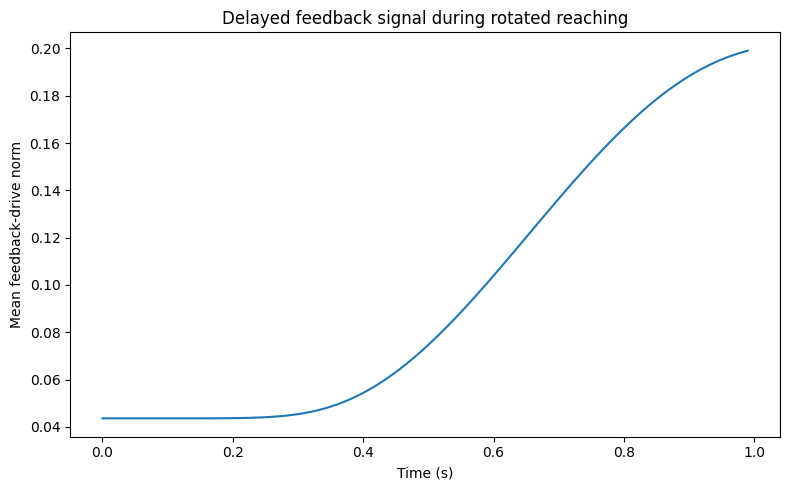

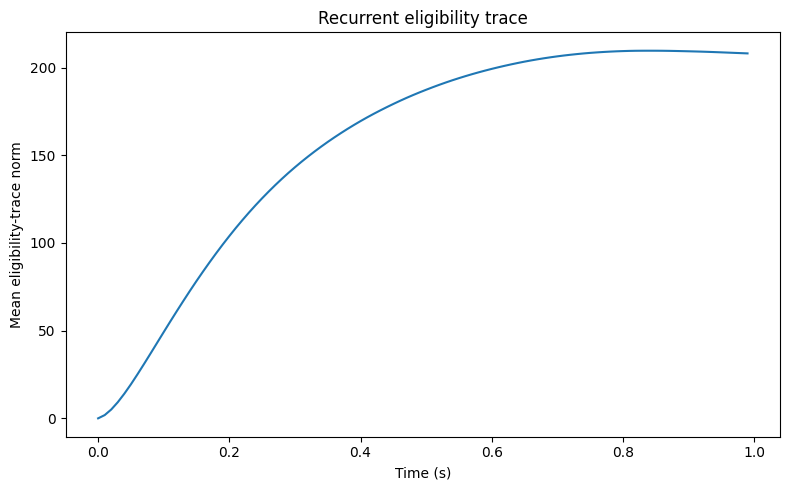

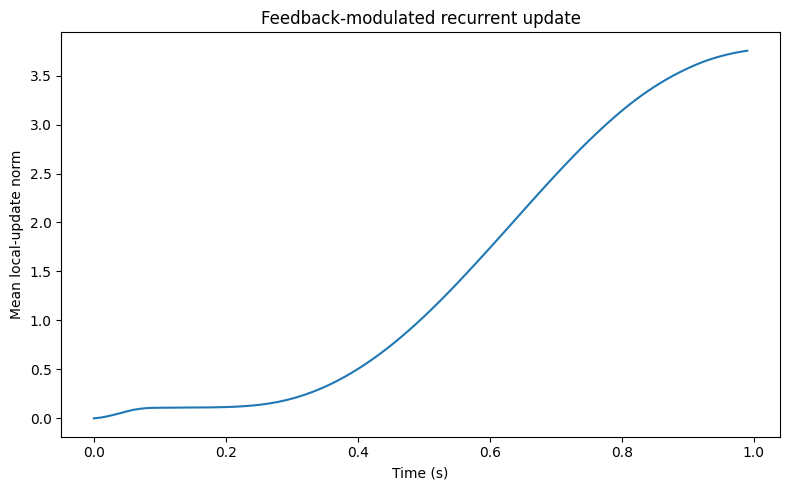

In [ ]:
# ============================================================
# STEP 13: LOCAL FEEDBACK-DRIVEN RECURRENT PLASTICITY
# ============================================================

import copy
import numpy as np
import matplotlib.pyplot as plt
import torch as th


def rollout_visuomotor_rotation_for_plasticity(
    env,
    policy,
    batch_size: int,
    rotation_degrees: float = 0.0,
    feedback_enabled: bool = True,
):
    """
    Run a visuomotor-rotation batch and record the local variables
    required for recurrent plasticity.

    No gradients or BPTT are used.

    Recorded at each timestep:
        pre_rates:
            recurrent rates before the state update

        post_states:
            recurrent state x after the state update

        post_rates:
            recurrent rates after the state update

        delayed_errors:
            delayed 2-D visual error

        feedback_drives:
            delayed error projected into recurrent units
    """

    with th.no_grad():

        obs, info = env.reset(
            options={"batch_size": int(batch_size)}
        )

        obs = obs.to(policy.device)

        start_position = (
            info["states"]["fingertip"]
            .to(policy.device)
            .clone()
        )

        goal_position = (
            info["goal"]
            .to(policy.device)
            .clone()
        )

        desired_position = minimum_jerk_trajectory(
            start_position=start_position,
            target_position=goal_position,
            n_steps=n_episode_steps,
            device=policy.device,
        )

        h = policy.init_hidden(batch_size)
        h["feedback_enabled"] = bool(feedback_enabled)

        true_positions = [start_position[:, None, :]]
        displayed_positions = [start_position[:, None, :]]

        actions = []
        visual_errors = []

        pre_rates = []
        post_states = []
        post_rates = []

        delayed_errors = []
        feedback_drives = []

        terminated = False
        step = 0

        while not terminated:

            if step >= n_episode_steps:
                raise RuntimeError(
                    "Environment exceeded expected episode length."
                )

            true_hand = (
                info["states"]["fingertip"]
                .to(policy.device)
            )

            displayed_cursor = rotate_cursor_about_start(
                hand_position=true_hand,
                start_position=start_position,
                rotation_degrees=rotation_degrees,
            )

            desired_now = desired_position[:, step, :]

            visual_error = (
                desired_now
                - displayed_cursor
            )

            h = policy.set_feedback_error(
                h=h,
                visual_error=visual_error,
            )

            policy_input = obs.clone()

            # Hide the true cursor and expose only the rotated cursor.
            policy_input[:, 2:4] = displayed_cursor

            # Presynaptic recurrent activity entering this update.
            r_before = h["r"].clone()

            action, h = policy(
                policy_input,
                h,
            )

            # Store local variables after the recurrent update.
            pre_rates.append(
                r_before[:, None, :]
            )

            post_states.append(
                h["x"].clone()[:, None, :]
            )

            post_rates.append(
                h["r"].clone()[:, None, :]
            )

            delayed_errors.append(
                h["delayed_error"].clone()[:, None, :]
            )

            feedback_drives.append(
                h["feedback_drive"].clone()[:, None, :]
            )

            obs, reward, terminated, truncated, info = env.step(
                action=action
            )

            obs = obs.to(policy.device)

            next_true_hand = (
                info["states"]["fingertip"]
                .to(policy.device)
            )

            next_displayed_cursor = rotate_cursor_about_start(
                hand_position=next_true_hand,
                start_position=start_position,
                rotation_degrees=rotation_degrees,
            )

            true_positions.append(
                next_true_hand[:, None, :]
            )

            displayed_positions.append(
                next_displayed_cursor[:, None, :]
            )

            actions.append(
                action[:, None, :]
            )

            visual_errors.append(
                visual_error[:, None, :]
            )

            step += 1

        true_positions = th.cat(
            true_positions,
            dim=1,
        )

        displayed_positions = th.cat(
            displayed_positions,
            dim=1,
        )

        target_vector = (
            goal_position
            - start_position
        )

        hand_vector = (
            true_positions[:, -1, :]
            - start_position
        )

        displayed_vector = (
            displayed_positions[:, -1, :]
            - start_position
        )

        def signed_angle_degrees(vector_a, vector_b):

            cross = (
                vector_a[:, 0] * vector_b[:, 1]
                - vector_a[:, 1] * vector_b[:, 0]
            )

            dot = th.sum(
                vector_a * vector_b,
                dim=-1,
            )

            return th.rad2deg(
                th.atan2(cross, dot)
            )

        hand_angular_error = signed_angle_degrees(
            target_vector,
            hand_vector,
        )

        displayed_angular_error = signed_angle_degrees(
            target_vector,
            displayed_vector,
        )

        endpoint_distance = th.linalg.vector_norm(
            true_positions[:, -1, :]
            - goal_position,
            dim=-1,
        )

        displayed_endpoint_distance = th.linalg.vector_norm(
            displayed_positions[:, -1, :]
            - goal_position,
            dim=-1,
        )

        return {
            "hand_position": true_positions,
            "displayed_position": displayed_positions,
            "desired_position": desired_position,

            "actions": th.cat(actions, dim=1),
            "visual_errors": th.cat(visual_errors, dim=1),

            "pre_rates": th.cat(pre_rates, dim=1),
            "post_states": th.cat(post_states, dim=1),
            "post_rates": th.cat(post_rates, dim=1),

            "delayed_errors": th.cat(
                delayed_errors,
                dim=1,
            ),

            "feedback_drives": th.cat(
                feedback_drives,
                dim=1,
            ),

            "start_position": start_position,
            "goal_position": goal_position,

            "hand_angular_error": hand_angular_error,
            "displayed_angular_error": displayed_angular_error,

            "endpoint_distance": endpoint_distance,
            "displayed_endpoint_distance": (
                displayed_endpoint_distance
            ),
        }


def compute_feedback_driven_recurrent_update(
    rollout,
    policy,
    learning_rate: float = 1e-5,
    eligibility_tau: float = 0.20,
    update_clip_norm: float | None = 0.01,
    normalize_by_time: bool = True,
):
    """
    Compute a local recurrent-weight update without BPTT.

    For recurrent weight W[j, i]:

        eligibility[j, i] ~
            post_activation_derivative[j]
            * presynaptic_rate[i]

        delta_W[j, i] ~
            feedback_drive[j]
            * eligibility[j, i]

    Shapes
    ------
    pre_rates:
        [batch, time, hidden]

    post_states:
        [batch, time, hidden]

    feedback_drives:
        [batch, time, hidden]

    returned delta_W:
        [hidden, hidden]
    """

    if learning_rate <= 0:
        raise ValueError(
            "learning_rate must be positive."
        )

    if eligibility_tau <= 0:
        raise ValueError(
            "eligibility_tau must be positive."
        )

    pre_rates_tensor = rollout["pre_rates"]
    post_states_tensor = rollout["post_states"]
    feedback_tensor = rollout["feedback_drives"]

    batch_size, time_steps, hidden_dim = (
        pre_rates_tensor.shape
    )

    if hidden_dim != policy.hidden_dim:
        raise ValueError(
            "Rollout hidden dimension does not match policy."
        )

    eligibility_decay = float(
        np.exp(
            -policy.dt
            / eligibility_tau
        )
    )

    eligibility = th.zeros(
        batch_size,
        hidden_dim,
        hidden_dim,
        device=policy.device,
        dtype=pre_rates_tensor.dtype,
    )

    accumulated_update = th.zeros_like(
        eligibility
    )

    eligibility_norm_history = []
    update_norm_history = []
    feedback_norm_history = []

    with th.no_grad():

        for step in range(time_steps):

            presynaptic_rate = (
                pre_rates_tensor[:, step, :]
            )

            postsynaptic_state = (
                post_states_tensor[:, step, :]
            )

            feedback_drive = (
                feedback_tensor[:, step, :]
            )

            # Derivative of ReLU(x).
            postsynaptic_derivative = (
                postsynaptic_state > 0
            ).to(
                postsynaptic_state.dtype
            )

            # [batch, post, pre]
            instantaneous_eligibility = (
                postsynaptic_derivative[:, :, None]
                * presynaptic_rate[:, None, :]
            )

            eligibility = (
                eligibility_decay
                * eligibility
                + policy.alpha
                * instantaneous_eligibility
            )

            # Three-factor local update:
            # feedback_j * eligibility_ji
            timestep_update = (
                feedback_drive[:, :, None]
                * eligibility
            )

            accumulated_update += timestep_update

            eligibility_norm_history.append(
                eligibility.flatten(1).norm(
                    dim=1
                ).mean()
            )

            update_norm_history.append(
                timestep_update.flatten(1).norm(
                    dim=1
                ).mean()
            )

            feedback_norm_history.append(
                feedback_drive.norm(
                    dim=1
                ).mean()
            )

        # Average over trials.
        delta_weight = (
            accumulated_update.mean(dim=0)
        )

        if normalize_by_time:
            delta_weight = (
                delta_weight
                / float(time_steps)
            )

        delta_weight = (
            learning_rate
            * delta_weight
        )

        raw_update_norm = (
            delta_weight.norm()
        )

        if (
            update_clip_norm is not None
            and raw_update_norm > update_clip_norm
        ):
            delta_weight = (
                delta_weight
                * (
                    update_clip_norm
                    / (
                        raw_update_norm
                        + 1e-12
                    )
                )
            )

        final_update_norm = (
            delta_weight.norm()
        )

    diagnostics = {
        "eligibility_decay": eligibility_decay,

        "raw_update_norm": (
            float(raw_update_norm.cpu())
        ),

        "final_update_norm": (
            float(final_update_norm.cpu())
        ),

        "mean_abs_update": (
            float(
                delta_weight.abs()
                .mean()
                .cpu()
            )
        ),

        "max_abs_update": (
            float(
                delta_weight.abs()
                .max()
                .cpu()
            )
        ),

        "eligibility_norm_history": th.stack(
            eligibility_norm_history
        ).cpu(),

        "timestep_update_norm_history": th.stack(
            update_norm_history
        ).cpu(),

        "feedback_norm_history": th.stack(
            feedback_norm_history
        ).cpu(),
    }

    return delta_weight, diagnostics


def apply_recurrent_update(
    policy,
    delta_weight: th.Tensor,
):
    """
    Apply a precomputed local update to the recurrent matrix.
    """

    expected_shape = (
        policy.hidden_dim,
        policy.hidden_dim,
    )

    if delta_weight.shape != expected_shape:
        raise ValueError(
            f"delta_weight shape is "
            f"{tuple(delta_weight.shape)}, "
            f"expected {expected_shape}."
        )

    with th.no_grad():

        policy.recurrent_layer.weight.add_(
            delta_weight.to(
                device=policy.device,
                dtype=policy.recurrent_layer.weight.dtype,
            )
        )


# ============================================================
# ONE-UPDATE DIAGNOSTIC TEST
# ============================================================

feedback_policy.eval()

test_rotation_degrees = 30.0
test_batch_size = 64

# Start conservatively.
test_plasticity_learning_rate = 1e-5
test_eligibility_tau = 0.20
test_update_clip_norm = 0.01


# Save the original recurrent matrix.
recurrent_weight_before = (
    feedback_policy.recurrent_layer.weight
    .detach()
    .clone()
)


# Run one rotated batch.
plasticity_rollout = (
    rollout_visuomotor_rotation_for_plasticity(
        env=env,
        policy=feedback_policy,
        batch_size=test_batch_size,
        rotation_degrees=test_rotation_degrees,
        feedback_enabled=True,
    )
)


# Compute the local update.
delta_W, plasticity_diagnostics = (
    compute_feedback_driven_recurrent_update(
        rollout=plasticity_rollout,
        policy=feedback_policy,
        learning_rate=test_plasticity_learning_rate,
        eligibility_tau=test_eligibility_tau,
        update_clip_norm=test_update_clip_norm,
        normalize_by_time=True,
    )
)


print("One-batch plasticity diagnostic")
print("--------------------------------")

print(
    "Mean displayed angular error:",
    plasticity_rollout[
        "displayed_angular_error"
    ].mean().item(),
    "degrees",
)

print(
    "Mean physical angular error: ",
    plasticity_rollout[
        "hand_angular_error"
    ].mean().item(),
    "degrees",
)

print(
    "Recurrent weight norm:       ",
    recurrent_weight_before.norm().item(),
)

print(
    "Raw update norm:             ",
    plasticity_diagnostics[
        "raw_update_norm"
    ],
)

print(
    "Final update norm:           ",
    plasticity_diagnostics[
        "final_update_norm"
    ],
)

print(
    "Mean absolute update:        ",
    plasticity_diagnostics[
        "mean_abs_update"
    ],
)

print(
    "Maximum absolute update:     ",
    plasticity_diagnostics[
        "max_abs_update"
    ],
)

print(
    "Relative update size:        ",
    plasticity_diagnostics[
        "final_update_norm"
    ]
    / (
        recurrent_weight_before.norm().item()
        + 1e-12
    ),
)


# ============================================================
# TEMPORARILY APPLY THE UPDATE AND VERIFY IT
# ============================================================

apply_recurrent_update(
    policy=feedback_policy,
    delta_weight=delta_W,
)

recurrent_weight_after = (
    feedback_policy.recurrent_layer.weight
    .detach()
    .clone()
)

measured_change = (
    recurrent_weight_after
    - recurrent_weight_before
)

print("\nUpdate application check")
print("------------------------")

print(
    "Expected ΔW norm:",
    delta_W.norm().item(),
)

print(
    "Measured ΔW norm:",
    measured_change.norm().item(),
)

print(
    "Maximum discrepancy:",
    (
        measured_change
        - delta_W
    ).abs().max().item(),
)


# Restore the original controller.
with th.no_grad():
    feedback_policy.recurrent_layer.weight.copy_(
        recurrent_weight_before
    )

print("\nOriginal recurrent weights restored.")


# ============================================================
# PLOT LOCAL SIGNALS OVER THE REACH
# ============================================================

time_axis = (
    np.arange(n_episode_steps)
    * feedback_policy.dt
)

plt.figure(figsize=(8, 5))

plt.plot(
    time_axis,
    plasticity_diagnostics[
        "feedback_norm_history"
    ].numpy(),
)

plt.xlabel("Time (s)")
plt.ylabel("Mean feedback-drive norm")
plt.title("Delayed feedback signal during rotated reaching")
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))

plt.plot(
    time_axis,
    plasticity_diagnostics[
        "eligibility_norm_history"
    ].numpy(),
)

plt.xlabel("Time (s)")
plt.ylabel("Mean eligibility-trace norm")
plt.title("Recurrent eligibility trace")
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))

plt.plot(
    time_axis,
    plasticity_diagnostics[
        "timestep_update_norm_history"
    ].numpy(),
)

plt.xlabel("Time (s)")
plt.ylabel("Mean local-update norm")
plt.title("Feedback-modulated recurrent update")
plt.tight_layout()
plt.show()

Plasticity-sign pilot
---------------------
Positive sign: early=29.162°, late=28.740°, improvement=0.421°
Negative sign: early=29.074°, late=28.962°, improvement=0.112°

Selected update sign: 1.0

Running baseline...
Baseline   1/30 | displayed angle  -0.297° | endpoint 0.0111
Baseline  10/30 | displayed angle   0.541° | endpoint 0.0140
Baseline  20/30 | displayed angle   0.109° | endpoint 0.0144
Baseline  30/30 | displayed angle  -0.051° | endpoint 0.0124

Running rotation adaptation...
Rotation   1/200 | displayed angle  29.283° | physical angle  -0.717° | ΔW norm 5.067e-04
Rotation  20/200 | displayed angle  28.815° | physical angle  -1.185° | ΔW norm 4.075e-04
Rotation  40/200 | displayed angle  29.227° | physical angle  -0.773° | ΔW norm 4.520e-04
Rotation  60/200 | displayed angle  28.621° | physical angle  -1.379° | ΔW norm 3.866e-04
Rotation  80/200 | displayed angle  28.882° | physical angle  -1.118° | ΔW norm 3.771e-04
Rotation 100/200 | displayed angle  28.698° | physical a

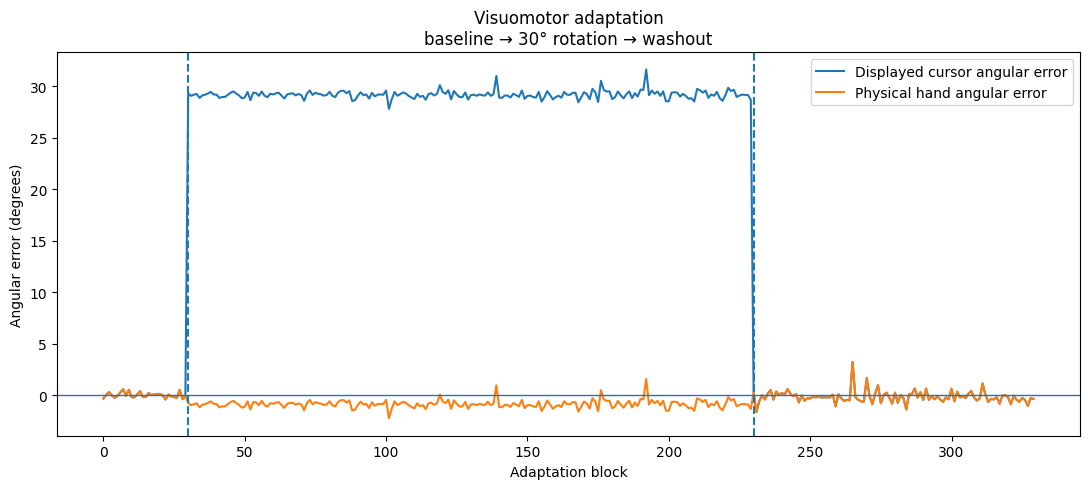

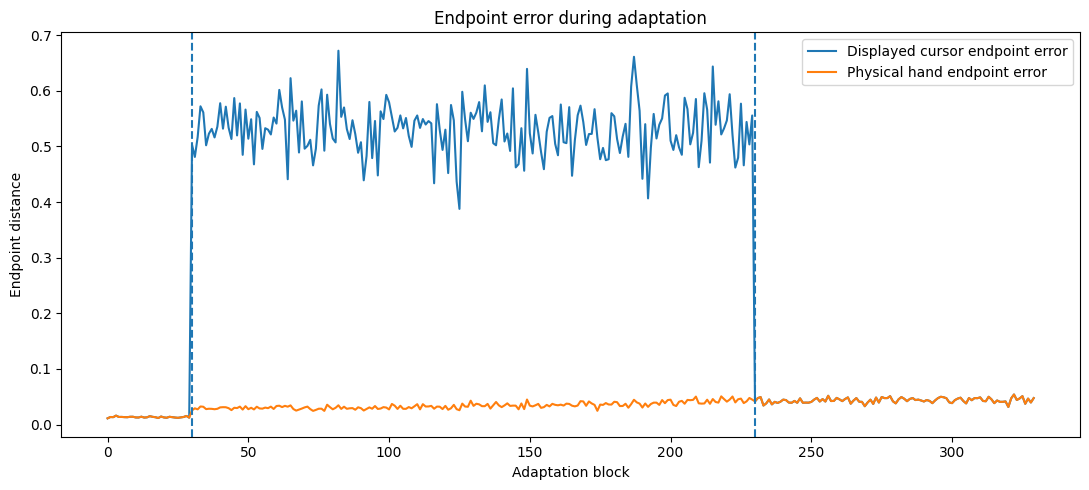

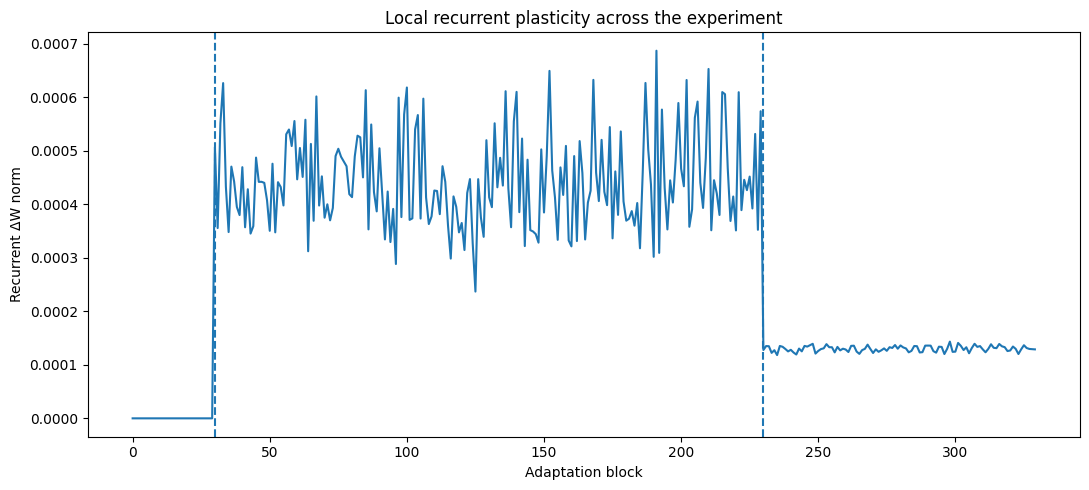

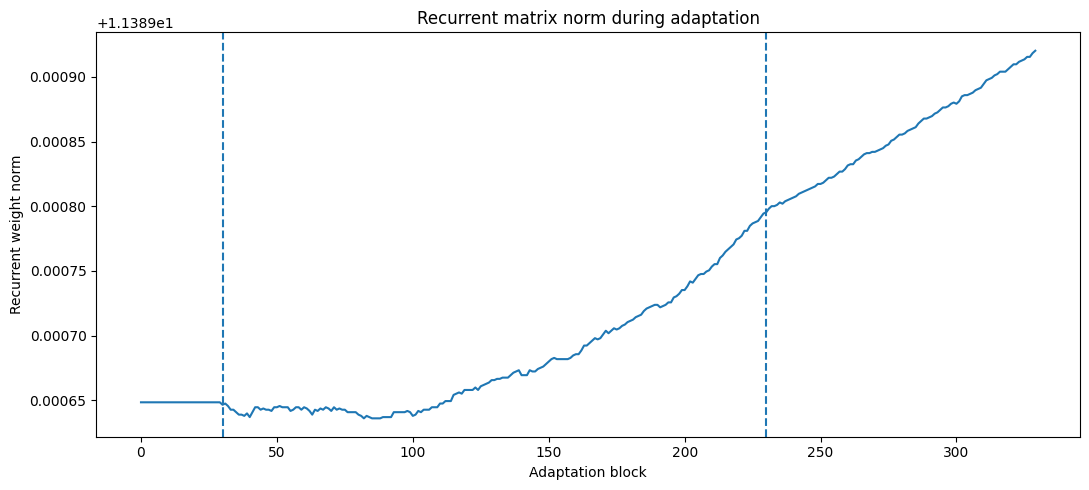

In [ ]:
# ============================================================
# STEP 14: BASELINE -> ROTATION -> WASHOUT ADAPTATION
# ============================================================

import copy
import random
import numpy as np
import matplotlib.pyplot as plt
import torch as th


# ============================================================
# SETTINGS
# ============================================================

adaptation_rotation_degrees = 30.0
adaptation_batch_size = 32

baseline_blocks = 30
rotation_blocks = 200
washout_blocks = 100

# Larger than the diagnostic value of 1e-5.
# The update is still clipped for stability.
plasticity_learning_rate = 1e-3
plasticity_eligibility_tau = 0.20
plasticity_update_clip_norm = 0.01

# Briefly test both possible update signs.
sign_test_blocks = 20

experiment_seed = 1234


# ============================================================
# REPRODUCIBILITY HELPER
# ============================================================

def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    th.manual_seed(seed)

    if th.cuda.is_available():
        th.cuda.manual_seed_all(seed)


# ============================================================
# RUN ONE ADAPTATION BLOCK
# ============================================================

def run_adaptation_block(
    env,
    policy,
    rotation_degrees,
    batch_size,
    plasticity_enabled,
    update_sign,
    learning_rate,
    eligibility_tau,
    update_clip_norm,
):
    """
    Run one batch of reaching movements.

    After the movements, optionally apply one local recurrent
    weight update.

    Returns block-averaged behavioral metrics and update statistics.
    """

    rollout = rollout_visuomotor_rotation_for_plasticity(
        env=env,
        policy=policy,
        batch_size=batch_size,
        rotation_degrees=rotation_degrees,
        feedback_enabled=True,
    )

    metrics = {
        "physical_angular_error": float(
            rollout["hand_angular_error"].mean().cpu()
        ),
        "displayed_angular_error": float(
            rollout["displayed_angular_error"].mean().cpu()
        ),
        "physical_endpoint_distance": float(
            rollout["endpoint_distance"].mean().cpu()
        ),
        "displayed_endpoint_distance": float(
            rollout["displayed_endpoint_distance"].mean().cpu()
        ),
        "update_norm": 0.0,
        "relative_update_norm": 0.0,
    }

    if plasticity_enabled:

        delta_W, diagnostics = (
            compute_feedback_driven_recurrent_update(
                rollout=rollout,
                policy=policy,
                learning_rate=learning_rate,
                eligibility_tau=eligibility_tau,
                update_clip_norm=update_clip_norm,
                normalize_by_time=True,
            )
        )

        delta_W = float(update_sign) * delta_W

        weight_norm_before = float(
            policy.recurrent_layer.weight.detach().norm().cpu()
        )

        apply_recurrent_update(
            policy=policy,
            delta_weight=delta_W,
        )

        metrics["update_norm"] = float(
            delta_W.norm().cpu()
        )

        metrics["relative_update_norm"] = (
            metrics["update_norm"]
            / (weight_norm_before + 1e-12)
        )

    return metrics


# ============================================================
# AUTOMATICALLY DETERMINE THE UPDATE SIGN
# ============================================================

feedback_policy.eval()

original_recurrent_weights = (
    feedback_policy.recurrent_layer.weight
    .detach()
    .clone()
)


def evaluate_update_sign(update_sign):
    """
    Start from identical recurrent weights and run a short
    rotation-adaptation pilot.
    """

    with th.no_grad():
        feedback_policy.recurrent_layer.weight.copy_(
            original_recurrent_weights
        )

    # Reset seeds so the + and - sign pilots see comparable
    # random-number sequences.
    set_all_seeds(experiment_seed)

    displayed_errors = []

    for block in range(sign_test_blocks):

        block_metrics = run_adaptation_block(
            env=env,
            policy=feedback_policy,
            rotation_degrees=adaptation_rotation_degrees,
            batch_size=adaptation_batch_size,
            plasticity_enabled=True,
            update_sign=update_sign,
            learning_rate=plasticity_learning_rate,
            eligibility_tau=plasticity_eligibility_tau,
            update_clip_norm=plasticity_update_clip_norm,
        )

        displayed_errors.append(
            block_metrics["displayed_angular_error"]
        )

    early_error = float(
        np.mean(displayed_errors[:5])
    )

    late_error = float(
        np.mean(displayed_errors[-5:])
    )

    improvement = (
        abs(early_error)
        - abs(late_error)
    )

    return {
        "sign": update_sign,
        "errors": displayed_errors,
        "early_error": early_error,
        "late_error": late_error,
        "improvement": improvement,
    }


positive_sign_test = evaluate_update_sign(+1.0)
negative_sign_test = evaluate_update_sign(-1.0)


print("Plasticity-sign pilot")
print("---------------------")

print(
    "Positive sign:"
    f" early={positive_sign_test['early_error']:.3f}°,"
    f" late={positive_sign_test['late_error']:.3f}°,"
    f" improvement={positive_sign_test['improvement']:.3f}°"
)

print(
    "Negative sign:"
    f" early={negative_sign_test['early_error']:.3f}°,"
    f" late={negative_sign_test['late_error']:.3f}°,"
    f" improvement={negative_sign_test['improvement']:.3f}°"
)


if (
    positive_sign_test["improvement"]
    >= negative_sign_test["improvement"]
):
    selected_update_sign = +1.0
else:
    selected_update_sign = -1.0


print(
    "\nSelected update sign:",
    selected_update_sign,
)


# ============================================================
# RESTORE THE PRE-ADAPTATION CONTROLLER
# ============================================================

with th.no_grad():
    feedback_policy.recurrent_layer.weight.copy_(
        original_recurrent_weights
    )

set_all_seeds(experiment_seed)


# ============================================================
# EXPERIMENT STORAGE
# ============================================================

history = {
    "phase": [],
    "rotation_degrees": [],
    "physical_angular_error": [],
    "displayed_angular_error": [],
    "physical_endpoint_distance": [],
    "displayed_endpoint_distance": [],
    "update_norm": [],
    "relative_update_norm": [],
    "recurrent_weight_norm": [],
}


def store_block(
    phase_name,
    rotation_degrees,
    metrics,
):
    history["phase"].append(phase_name)
    history["rotation_degrees"].append(rotation_degrees)

    for key in [
        "physical_angular_error",
        "displayed_angular_error",
        "physical_endpoint_distance",
        "displayed_endpoint_distance",
        "update_norm",
        "relative_update_norm",
    ]:
        history[key].append(metrics[key])

    history["recurrent_weight_norm"].append(
        float(
            feedback_policy.recurrent_layer.weight
            .detach()
            .norm()
            .cpu()
        )
    )


# ============================================================
# BASELINE
# No visuomotor rotation and no plasticity.
# ============================================================

print("\nRunning baseline...")

for block in range(baseline_blocks):

    metrics = run_adaptation_block(
        env=env,
        policy=feedback_policy,
        rotation_degrees=0.0,
        batch_size=adaptation_batch_size,
        plasticity_enabled=False,
        update_sign=selected_update_sign,
        learning_rate=plasticity_learning_rate,
        eligibility_tau=plasticity_eligibility_tau,
        update_clip_norm=plasticity_update_clip_norm,
    )

    store_block(
        phase_name="baseline",
        rotation_degrees=0.0,
        metrics=metrics,
    )

    if (
        block == 0
        or (block + 1) % 10 == 0
    ):
        print(
            f"Baseline {block + 1:3d}/{baseline_blocks} | "
            f"displayed angle "
            f"{metrics['displayed_angular_error']:7.3f}° | "
            f"endpoint "
            f"{metrics['displayed_endpoint_distance']:.4f}"
        )


# ============================================================
# ROTATION ADAPTATION
# Constant 30-degree cursor rotation with recurrent plasticity.
# ============================================================

print("\nRunning rotation adaptation...")

for block in range(rotation_blocks):

    metrics = run_adaptation_block(
        env=env,
        policy=feedback_policy,
        rotation_degrees=adaptation_rotation_degrees,
        batch_size=adaptation_batch_size,
        plasticity_enabled=True,
        update_sign=selected_update_sign,
        learning_rate=plasticity_learning_rate,
        eligibility_tau=plasticity_eligibility_tau,
        update_clip_norm=plasticity_update_clip_norm,
    )

    store_block(
        phase_name="rotation",
        rotation_degrees=adaptation_rotation_degrees,
        metrics=metrics,
    )

    if (
        block == 0
        or (block + 1) % 20 == 0
    ):
        print(
            f"Rotation {block + 1:3d}/{rotation_blocks} | "
            f"displayed angle "
            f"{metrics['displayed_angular_error']:7.3f}° | "
            f"physical angle "
            f"{metrics['physical_angular_error']:7.3f}° | "
            f"ΔW norm "
            f"{metrics['update_norm']:.3e}"
        )


# Save adapted recurrent weights before washout.
rotation_adapted_recurrent_weights = (
    feedback_policy.recurrent_layer.weight
    .detach()
    .clone()
)


# ============================================================
# WASHOUT
# Remove the rotation but continue local plasticity.
# ============================================================

print("\nRunning washout...")

for block in range(washout_blocks):

    metrics = run_adaptation_block(
        env=env,
        policy=feedback_policy,
        rotation_degrees=0.0,
        batch_size=adaptation_batch_size,
        plasticity_enabled=True,
        update_sign=selected_update_sign,
        learning_rate=plasticity_learning_rate,
        eligibility_tau=plasticity_eligibility_tau,
        update_clip_norm=plasticity_update_clip_norm,
    )

    store_block(
        phase_name="washout",
        rotation_degrees=0.0,
        metrics=metrics,
    )

    if (
        block == 0
        or (block + 1) % 20 == 0
    ):
        print(
            f"Washout {block + 1:3d}/{washout_blocks} | "
            f"displayed angle "
            f"{metrics['displayed_angular_error']:7.3f}° | "
            f"physical angle "
            f"{metrics['physical_angular_error']:7.3f}° | "
            f"ΔW norm "
            f"{metrics['update_norm']:.3e}"
        )


# ============================================================
# SUMMARY
# ============================================================

phase_array = np.asarray(history["phase"])

baseline_mask = phase_array == "baseline"
rotation_mask = phase_array == "rotation"
washout_mask = phase_array == "washout"

displayed_angle_array = np.asarray(
    history["displayed_angular_error"]
)

physical_angle_array = np.asarray(
    history["physical_angular_error"]
)


print("\nAdaptation summary")
print("------------------")

print(
    "Baseline displayed angular error:",
    np.mean(displayed_angle_array[baseline_mask]),
    "degrees",
)

print(
    "Early rotation displayed error:",
    np.mean(
        displayed_angle_array[
            np.where(rotation_mask)[0][:10]
        ]
    ),
    "degrees",
)

print(
    "Late rotation displayed error:",
    np.mean(
        displayed_angle_array[
            np.where(rotation_mask)[0][-10:]
        ]
    ),
    "degrees",
)

print(
    "Late rotation physical angle:",
    np.mean(
        physical_angle_array[
            np.where(rotation_mask)[0][-10:]
        ]
    ),
    "degrees",
)

print(
    "Early washout physical angle:",
    np.mean(
        physical_angle_array[
            np.where(washout_mask)[0][:10]
        ]
    ),
    "degrees",
)

print(
    "Late washout physical angle:",
    np.mean(
        physical_angle_array[
            np.where(washout_mask)[0][-10:]
        ]
    ),
    "degrees",
)


# ============================================================
# PLOT 1: ANGULAR ADAPTATION
# ============================================================

block_axis = np.arange(len(history["phase"]))

rotation_start = baseline_blocks
washout_start = baseline_blocks + rotation_blocks

plt.figure(figsize=(11, 5))

plt.plot(
    block_axis,
    history["displayed_angular_error"],
    label="Displayed cursor angular error",
)

plt.plot(
    block_axis,
    history["physical_angular_error"],
    label="Physical hand angular error",
)

plt.axvline(
    rotation_start,
    linestyle="--",
)

plt.axvline(
    washout_start,
    linestyle="--",
)

plt.axhline(
    0.0,
    linewidth=1,
)

plt.xlabel("Adaptation block")
plt.ylabel("Angular error (degrees)")
plt.title(
    "Visuomotor adaptation\n"
    "baseline → 30° rotation → washout"
)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# PLOT 2: ENDPOINT ERROR
# ============================================================

plt.figure(figsize=(11, 5))

plt.plot(
    block_axis,
    history["displayed_endpoint_distance"],
    label="Displayed cursor endpoint error",
)

plt.plot(
    block_axis,
    history["physical_endpoint_distance"],
    label="Physical hand endpoint error",
)

plt.axvline(
    rotation_start,
    linestyle="--",
)

plt.axvline(
    washout_start,
    linestyle="--",
)

plt.xlabel("Adaptation block")
plt.ylabel("Endpoint distance")
plt.title("Endpoint error during adaptation")
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# PLOT 3: RECURRENT UPDATE SIZE
# ============================================================

plt.figure(figsize=(11, 5))

plt.plot(
    block_axis,
    history["update_norm"],
)

plt.axvline(
    rotation_start,
    linestyle="--",
)

plt.axvline(
    washout_start,
    linestyle="--",
)

plt.xlabel("Adaptation block")
plt.ylabel("Recurrent ΔW norm")
plt.title("Local recurrent plasticity across the experiment")
plt.tight_layout()
plt.show()


# ============================================================
# PLOT 4: RECURRENT WEIGHT NORM
# ============================================================

plt.figure(figsize=(11, 5))

plt.plot(
    block_axis,
    history["recurrent_weight_norm"],
)

plt.axvline(
    rotation_start,
    linestyle="--",
)

plt.axvline(
    washout_start,
    linestyle="--",
)

plt.xlabel("Adaptation block")
plt.ylabel("Recurrent weight norm")
plt.title("Recurrent matrix norm during adaptation")
plt.tight_layout()
plt.show()